In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as cx
import imageio
import os

from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.cluster import KMeans

In [3]:
data = pd.read_csv("nominal_data_dengue_2010.csv")
data_by_date = pd.read_csv("data_by_date.csv")
gdf = gpd.GeoDataFrame(
    data_by_date, geometry=gpd.points_from_xy(data["x"], data["y"]), crs="EPSG:4326"
)
gdf["x"] = data["x"]
gdf["y"] = data["y"]
gdf

,I_CUADRO,OBJECTID,Join_Count,TARGET_FID,ID_HILLO,ID_SON,ANYO,FOLIO,SEXO,EDAD,...,y,Unnamed: 69,day,week,month,year,dayofyear,FD,FHD,geometry
0,2010-01-30,1,1,217,231,6261,0,61,hombre,35,...,29.129075,NaN,30,4,1,2010,30,1,0,POINT (-110.95896 29.12907)
1,2010-05-06,3,1,219,233,6425,0,296,hombre,14,...,29.131731,NaN,6,18,5,2010,126,1,0,POINT (-110.96599 29.13173)
2,2010-05-09,2,1,218,232,6424,0,295,mujer,38,...,29.131733,NaN,9,18,5,2010,129,1,0,POINT (-110.96599 29.13173)
3,2010-06-04,4,1,220,234,6497,0,427,mujer,22,...,29.124453,NaN,4,22,6,2010,155,0,1,POINT (-110.97927 29.12445)
4,2010-07-04,6,2,222,236,6581,0,546,hombre,12,...,29.138764,NaN,4,26,7,2010,185,1,0,POINT (-110.96328 29.13876)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2723,2010-12-28,2345,2,2562,2688,11089,0,5648,mujer,66,...,29.113262,NaN,28,52,12,2010,362,1,0,POINT (-110.95999 29.11326)
2724,2010-12-28,2348,1,2565,2691,11093,0,5652,mujer,7,...,29.084639,NaN,28,52,12,2010,362,0,1,POINT (-110.94337 29.08464)
2725,2010-12-31,2352,1,2569,2695,11113,0,5676,mujer,41,...,29.136562,NaN,31,52,12,2010,365,1,0,POINT (-110.96156 29.13656)
2726,2010-12-31,2353,1,2570,2696,11114,0,5677,hombre,38,...,29.072824,NaN,31,52,12,2010,365,1,0,POINT (-110.95555 29.07282)


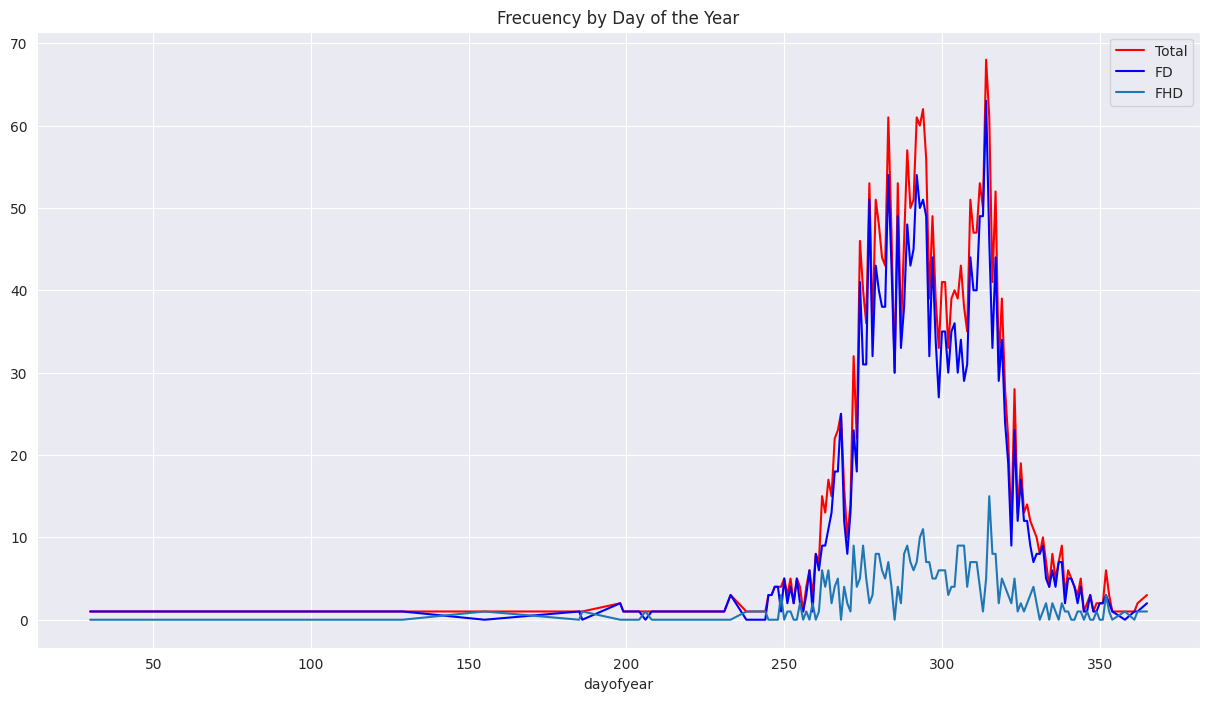

In [4]:
fig, ax = plt.subplots(figsize=(15,8))

gdf.groupby("dayofyear")["FD_FHD"].count().plot(ax=ax, color="red", label="Total")
gdf.groupby("dayofyear")["FD"].sum().plot(ax=ax, color="blue")
gdf.groupby("dayofyear")["FHD"].sum().plot(ax=ax)

plt.title("Frecuency by Day of the Year")
plt.legend()
plt.show()


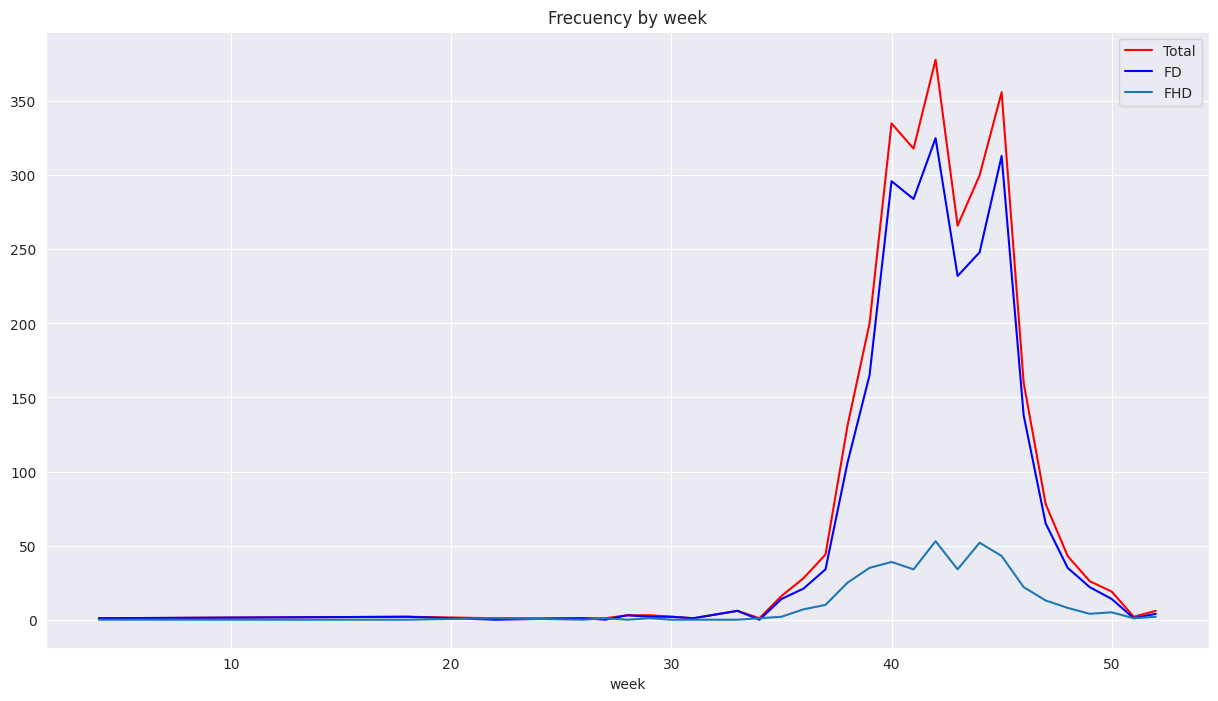

In [5]:
fig, ax = plt.subplots(figsize=(15,8))

gdf.groupby("week")["FD_FHD"].count().plot(ax=ax, color="red", label="Total")
gdf.groupby("week")["FD"].sum().plot(ax=ax, color="blue")
gdf.groupby("week")["FHD"].sum().plot(ax=ax)

plt.title("Frecuency by week")
plt.legend()
plt.show()

# Analysis by Day of Year

In [6]:
spike_data = gdf[gdf["I_CUADRO"] > "2010-08-28"]
spike_data = spike_data[spike_data["EDAD"] < 100]
spike_data.head()

,I_CUADRO,OBJECTID,Join_Count,TARGET_FID,ID_HILLO,ID_SON,ANYO,FOLIO,SEXO,EDAD,...,y,Unnamed: 69,day,week,month,year,dayofyear,FD,FHD,geometry
22,2010-08-30,20,1,236,250,6904,0,929,mujer,0,...,29.134184,NaN,30,35,8,2010,242,0,1,POINT (-111.0155 29.13418)
23,2010-09-01,25,1,241,255,6927,0,976,hombre,41,...,29.136228,NaN,1,35,9,2010,244,0,1,POINT (-110.96435 29.13623)
24,2010-09-02,26,1,242,256,6928,0,977,mujer,47,...,29.137403,NaN,2,35,9,2010,245,1,0,POINT (-110.96647 29.1374)
25,2010-09-02,27,1,243,257,6929,0,978,hombre,8,...,29.137217,NaN,2,35,9,2010,245,1,0,POINT (-110.96414 29.13722)
26,2010-09-02,33,1,249,262,6944,0,997,hombre,30,...,29.126753,NaN,2,35,9,2010,245,1,0,POINT (-110.9677 29.12675)


In [7]:
# Spike count by day

# Actual counts:
spike_count_by_day = pd.DataFrame(spike_data.groupby("dayofyear")["FD_FHD"].count())
spike_count_by_day["FD"] = spike_data.groupby("dayofyear")["FD"].sum()
spike_count_by_day["FHD"] = spike_data.groupby("dayofyear")["FHD"].sum()
# Cumulative total:
spike_count_by_day["FD_FHD_cumsum"] = spike_count_by_day["FD_FHD"].cumsum()
spike_count_by_day["FD_cumsum"] = spike_count_by_day["FD"].cumsum()
spike_count_by_day["FHD_cumsum"] = spike_count_by_day["FHD"].cumsum()
# Rolling mean:
spike_count_by_day["FD_FHD_mean"] = spike_count_by_day["FD_FHD"].rolling(7).mean()
spike_count_by_day["FD_mean"] = spike_count_by_day["FD"].rolling(7).mean()
spike_count_by_day["FHD_mean"] = spike_count_by_day["FHD"].rolling(7).mean()

spike_count_by_day.tail()

,FD_FHD,FD,FHD,FD_FHD_cumsum,FD_cumsum,FHD_cumsum,FD_FHD_mean,FD_mean,FHD_mean
dayofyear,,,,,,,,,
354,1,1,0,2698,2312,386,2.428571,1.714286,0.714286
358,1,0,1,2699,2312,387,2.428571,1.571429,0.857143
361,1,1,0,2700,2313,387,2.285714,1.571429,0.714286
362,2,1,1,2702,2314,388,2.285714,1.428571,0.857143
365,3,2,1,2705,2316,389,2.428571,1.428571,1.000000


In [8]:
division_1_day = 283 # 11/Oct./2010
division_2_day = 314 # 9/Nov./2010

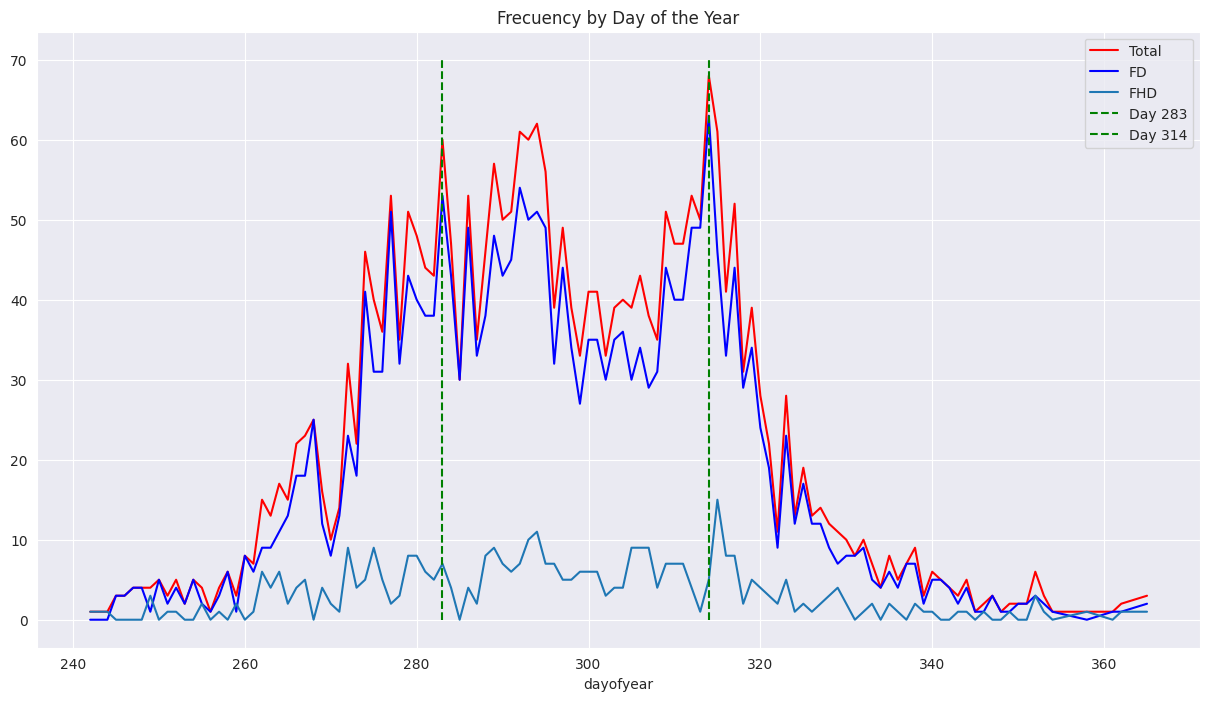

In [9]:
fig, ax = plt.subplots(figsize=(15,8))

spike_count_by_day["FD_FHD"].plot(ax=ax, color="red", label="Total")
spike_count_by_day["FD"].plot(ax=ax, color="blue")
spike_count_by_day["FHD"].plot(ax=ax)
plt.vlines(division_1_day, 0, 70, colors="green", linestyles='dashed', label=f"Day {division_1_day}")
plt.vlines(division_2_day, 0, 70, colors="green", linestyles='dashed', label=f"Day {division_2_day}")

plt.title("Frecuency by Day of the Year")
plt.legend()
plt.show()


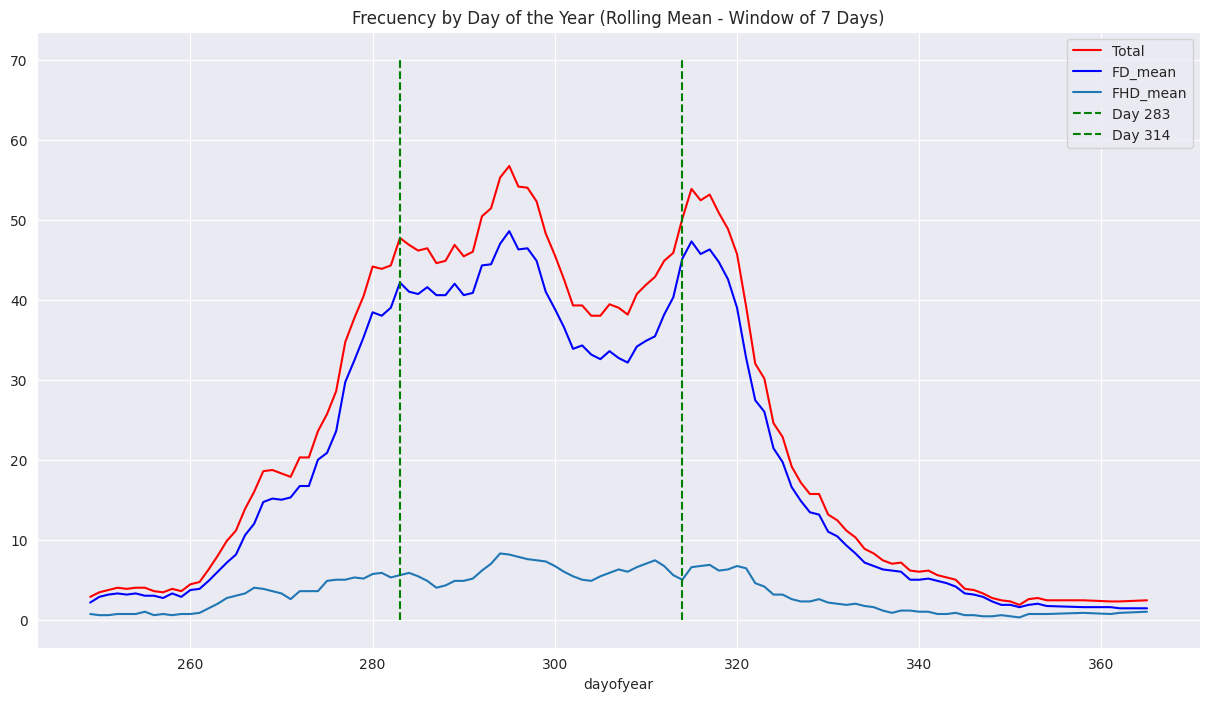

In [10]:
fig, ax = plt.subplots(figsize=(15,8))

spike_count_by_day["FD_FHD_mean"].plot(ax=ax, color="red", label="Total")
spike_count_by_day["FD_mean"].plot(ax=ax, color="blue")
spike_count_by_day["FHD_mean"].plot(ax=ax)
plt.vlines(division_1_day, 0, 70, colors="green", linestyles='dashed', label=f"Day {division_1_day}")
plt.vlines(division_2_day, 0, 70, colors="green", linestyles='dashed', label=f"Day {division_2_day}")

plt.title("Frecuency by Day of the Year (Rolling Mean - Window of 7 Days)")
plt.legend()
plt.show()


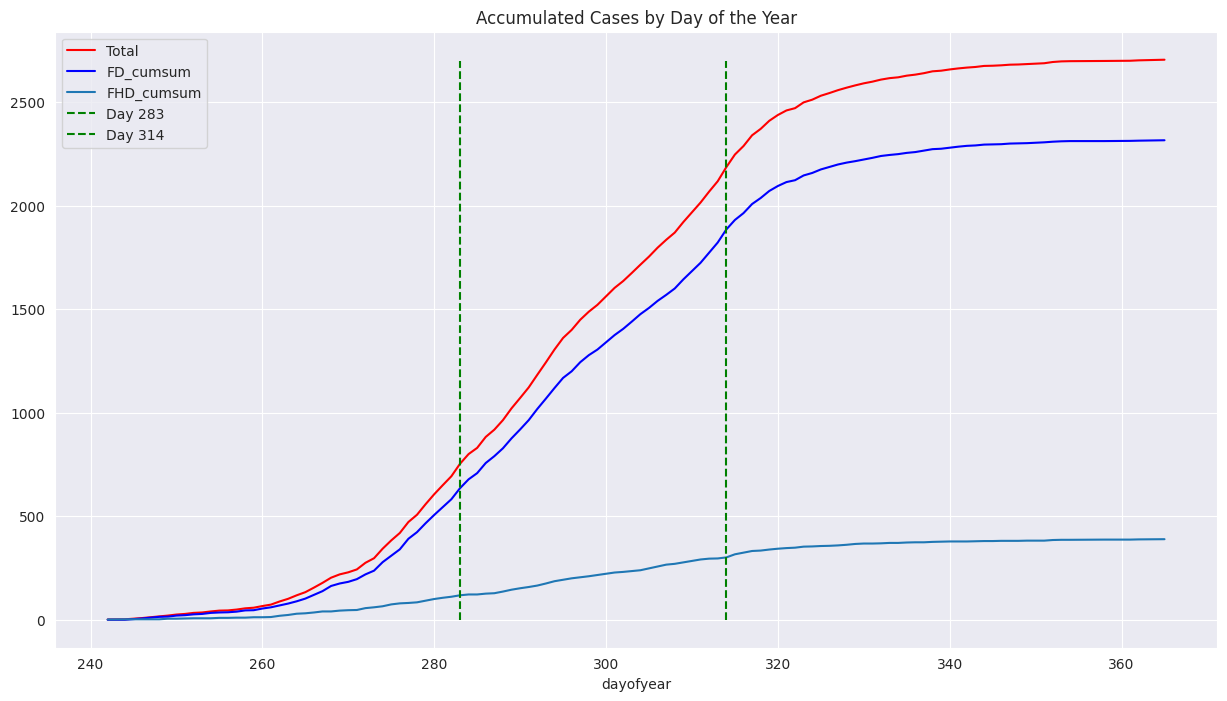

In [11]:
fig, ax = plt.subplots(figsize=(15,8))

spike_count_by_day["FD_FHD_cumsum"].plot(ax=ax, color="red", label="Total")
spike_count_by_day["FD_cumsum"].plot(ax=ax, color="blue")
spike_count_by_day["FHD_cumsum"].plot(ax=ax)
plt.vlines(division_1_day, 0, 2700, colors="green", linestyles='dashed', label=f"Day {division_1_day}")
plt.vlines(division_2_day, 0, 2700, colors="green", linestyles='dashed', label=f"Day {division_2_day}")

plt.title("Accumulated Cases by Day of the Year")
plt.legend()
plt.show()


In [12]:
data_sec_1 = spike_data[spike_data["I_CUADRO"] < "2010-10-11"]
data_sec_2 = spike_data[spike_data["I_CUADRO"] > "2010-10-11"][spike_data["I_CUADRO"] < "2010-11-09"]
data_sec_3 = spike_data[spike_data["I_CUADRO"] > "2010-11-09"]

/home/manuel/miniconda3/envs/fd_fhd_hmo_2010/lib/python3.12/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


In [13]:
# Spike count by day

# Actual counts:
data_sec_1_count = pd.DataFrame(data_sec_1.groupby("dayofyear")["FD_FHD"].count())
data_sec_1_count["FD"] = data_sec_1.groupby("dayofyear")["FD"].sum()
data_sec_1_count["FHD"] = data_sec_1.groupby("dayofyear")["FHD"].sum()
# Cumulative total:
data_sec_1_count["FD_FHD_cumsum"] = data_sec_1_count["FD_FHD"].cumsum()
data_sec_1_count["FD_cumsum"] = data_sec_1_count["FD"].cumsum()
data_sec_1_count["FHD_cumsum"] = data_sec_1_count["FHD"].cumsum()
# Rolling mean:
data_sec_1_count["FD_FHD_mean"] = data_sec_1_count["FD_FHD"].rolling(3).mean()
data_sec_1_count["FD_mean"] = data_sec_1_count["FD"].rolling(3).mean()
data_sec_1_count["FHD_mean"] = data_sec_1_count["FHD"].rolling(3).mean()

FD_FHD_cumsum_sec_1_total = data_sec_1_count["FD_FHD"].sum()
FD_cumsum_sec_1_total = data_sec_1_count["FD"].sum()
FHD_cumsum_sec_1_total = data_sec_1_count["FHD"].sum()

data_sec_1_count.tail()

,FD_FHD,FD,FHD,FD_FHD_cumsum,FD_cumsum,FHD_cumsum,FD_FHD_mean,FD_mean,FHD_mean
dayofyear,,,,,,,,,
279,51,43,8,558,466,92,46.333333,42.000000,4.333333
280,48,40,8,606,506,100,44.666667,38.333333,6.333333
281,44,38,6,650,544,106,47.666667,40.333333,7.333333
282,43,38,5,693,582,111,45.000000,38.666667,6.333333
283,60,53,7,753,635,118,49.000000,43.000000,6.000000


In [14]:
# Spike count by day

# Actual counts:
data_sec_2_count = pd.DataFrame(data_sec_2.groupby("dayofyear")["FD_FHD"].count())
data_sec_2_count["FD"] = data_sec_2.groupby("dayofyear")["FD"].sum()
data_sec_2_count["FHD"] = data_sec_2.groupby("dayofyear")["FHD"].sum()
# Cumulative total:
data_sec_2_count["FD_FHD_cumsum"] = data_sec_2_count["FD_FHD"].cumsum()
data_sec_2_count["FD_FHD_cumsum"] = data_sec_2_count["FD_FHD_cumsum"] + FD_FHD_cumsum_sec_1_total
data_sec_2_count["FD_cumsum"] = data_sec_2_count["FD"].cumsum()
data_sec_2_count["FD_cumsum"] = data_sec_2_count["FD_cumsum"] + FD_cumsum_sec_1_total
data_sec_2_count["FHD_cumsum"] = data_sec_2_count["FHD"].cumsum()
data_sec_2_count["FHD_cumsum"] = data_sec_2_count["FHD_cumsum"] + FHD_cumsum_sec_1_total
# Rolling mean:
data_sec_2_count["FD_FHD_mean"] = data_sec_2_count["FD_FHD"].rolling(3).mean()
data_sec_2_count["FD_mean"] = data_sec_2_count["FD"].rolling(3).mean()
data_sec_2_count["FHD_mean"] = data_sec_2_count["FHD"].rolling(3).mean()

FD_FHD_cumsum_sec_2_total = data_sec_2_count["FD_FHD"].sum()
FD_cumsum_sec_2_total = data_sec_2_count["FD"].sum()
FHD_cumsum_sec_2_total = data_sec_2_count["FHD"].sum()

data_sec_2_count.tail()

,FD_FHD,FD,FHD,FD_FHD_cumsum,FD_cumsum,FHD_cumsum,FD_FHD_mean,FD_mean,FHD_mean
dayofyear,,,,,,,,,
308,35,31,4,1823,1557,266,38.666667,31.333333,7.333333
309,51,44,7,1874,1601,273,41.333333,34.666667,6.666667
310,47,40,7,1921,1641,280,44.333333,38.333333,6.000000
311,47,40,7,1968,1681,287,48.333333,41.333333,7.000000
312,53,49,4,2021,1730,291,49.000000,43.000000,6.000000


In [15]:
# Spike count by day

# Actual counts:
data_sec_3_count = pd.DataFrame(data_sec_3.groupby("dayofyear")["FD_FHD"].count())
data_sec_3_count["FD"] = data_sec_3.groupby("dayofyear")["FD"].sum()
data_sec_3_count["FHD"] = data_sec_3.groupby("dayofyear")["FHD"].sum()
# Cumulative total:
data_sec_3_count["FD_FHD_cumsum"] = data_sec_3_count["FD_FHD"].cumsum()
data_sec_3_count["FD_FHD_cumsum"] = data_sec_3_count["FD_FHD_cumsum"] + FD_FHD_cumsum_sec_2_total
data_sec_3_count["FD_cumsum"] = data_sec_3_count["FD"].cumsum()
data_sec_3_count["FD_cumsum"] = data_sec_3_count["FD_cumsum"] + FD_cumsum_sec_2_total
data_sec_3_count["FHD_cumsum"] = data_sec_3_count["FHD"].cumsum()
data_sec_3_count["FHD_cumsum"] = data_sec_3_count["FHD_cumsum"] + FHD_cumsum_sec_2_total
# Rolling mean:
data_sec_3_count["FD_FHD_mean"] = data_sec_3_count["FD_FHD"].rolling(3).mean()
data_sec_3_count["FD_mean"] = data_sec_3_count["FD"].rolling(3).mean()
data_sec_3_count["FHD_mean"] = data_sec_3_count["FHD"].rolling(3).mean()

data_sec_3_count.tail()

,FD_FHD,FD,FHD,FD_FHD_cumsum,FD_cumsum,FHD_cumsum,FD_FHD_mean,FD_mean,FHD_mean
dayofyear,,,,,,,,,
354,1,1,0,1848,1585,263,3.333333,2.000000,1.333333
358,1,0,1,1849,1585,264,1.666667,1.000000,0.666667
361,1,1,0,1850,1586,264,1.000000,0.666667,0.333333
362,2,1,1,1852,1587,265,1.333333,0.666667,0.666667
365,3,2,1,1855,1589,266,2.000000,1.333333,0.666667


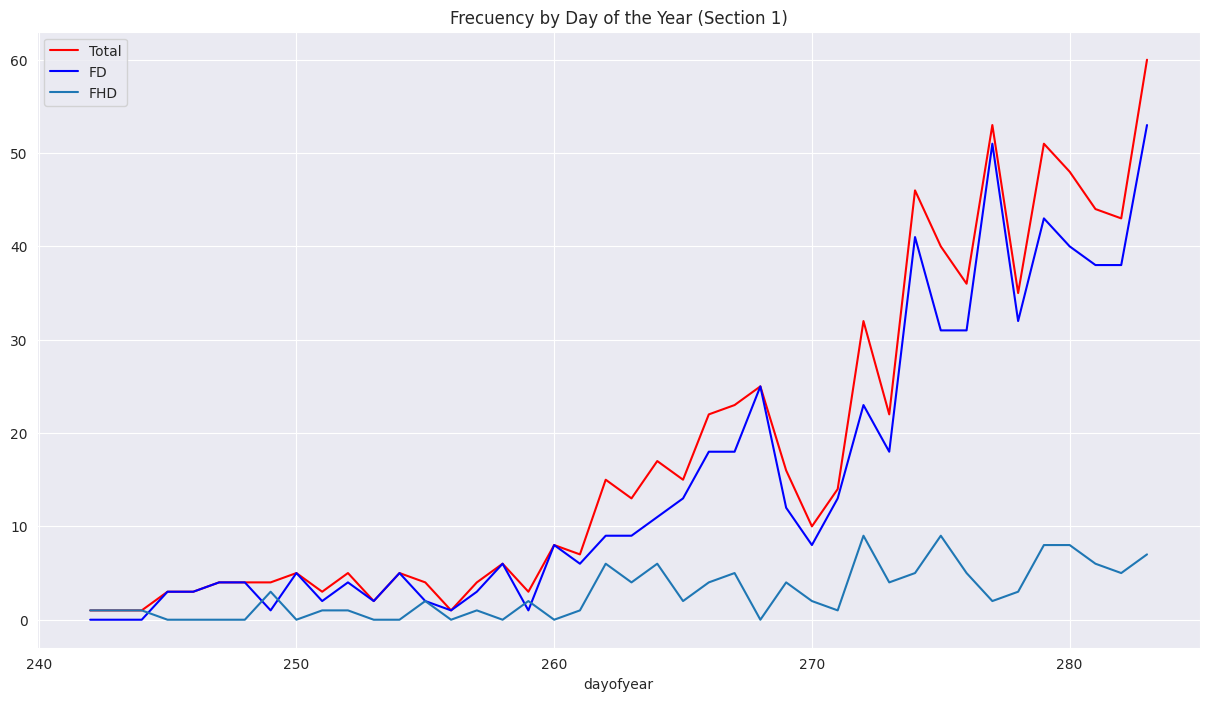

In [16]:
fig, ax = plt.subplots(figsize=(15,8))

data_sec_1_count["FD_FHD"].plot(ax=ax, color="red", label="Total")
data_sec_1_count["FD"].plot(ax=ax, color="blue")
data_sec_1_count["FHD"].plot(ax=ax)

plt.title("Frecuency by Day of the Year (Section 1)")
plt.legend()
plt.show()


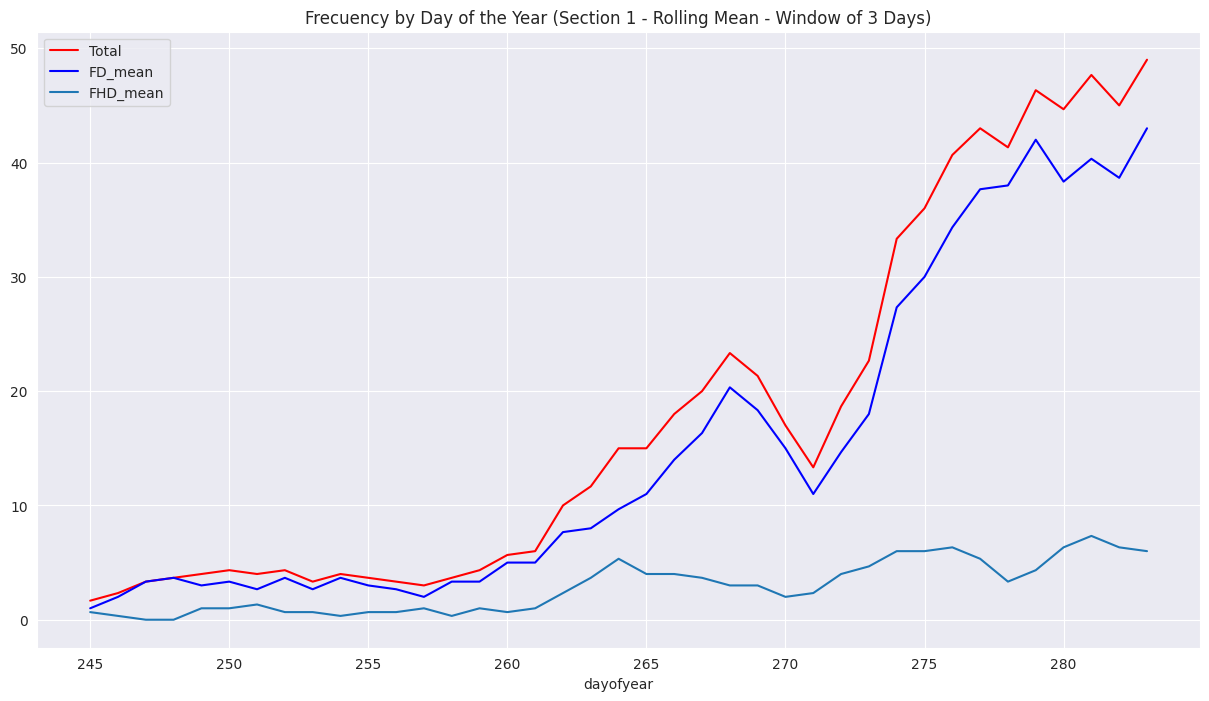

In [17]:
fig, ax = plt.subplots(figsize=(15,8))

data_sec_1_count["FD_FHD_mean"].plot(ax=ax, color="red", label="Total")
data_sec_1_count["FD_mean"].plot(ax=ax, color="blue")
data_sec_1_count["FHD_mean"].plot(ax=ax)

plt.title("Frecuency by Day of the Year (Section 1 - Rolling Mean - Window of 3 Days)")
plt.legend()
plt.show()


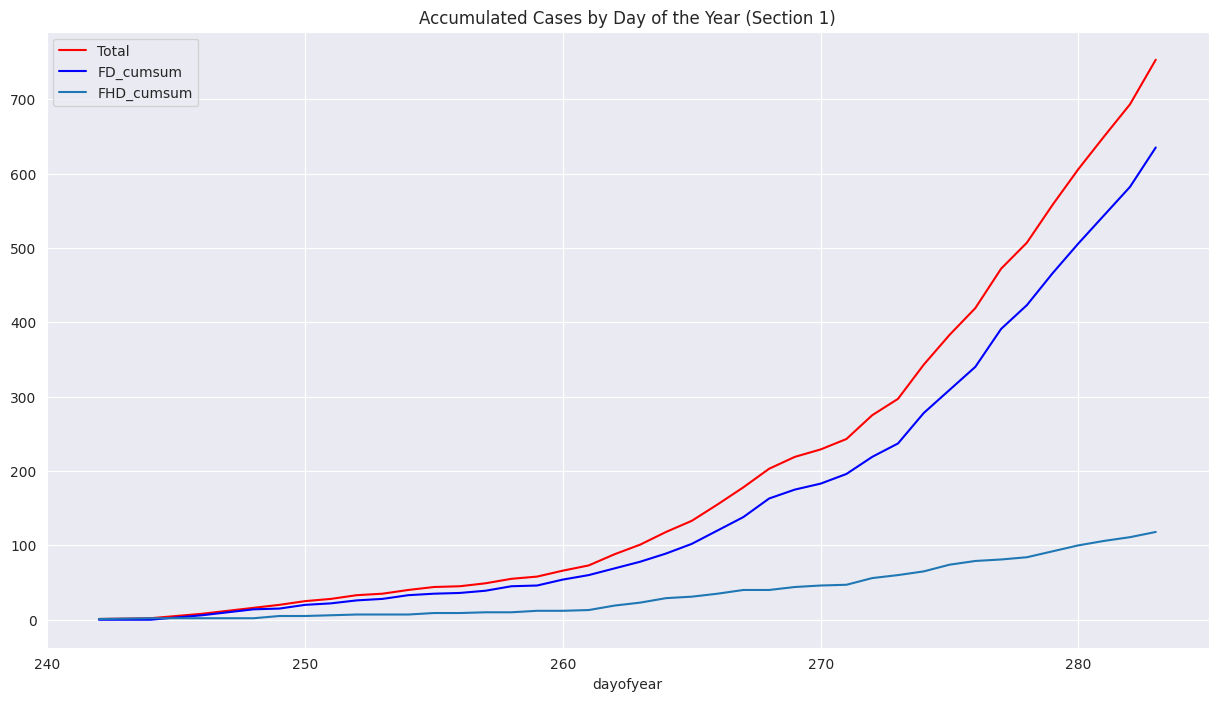

In [18]:
fig, ax = plt.subplots(figsize=(15,8))

data_sec_1_count["FD_FHD_cumsum"].plot(ax=ax, color="red", label="Total")
data_sec_1_count["FD_cumsum"].plot(ax=ax, color="blue")
data_sec_1_count["FHD_cumsum"].plot(ax=ax)
plt.title("Accumulated Cases by Day of the Year (Section 1)")
plt.legend()
plt.show()


In [19]:
kmeans_sec_1_df = data_sec_1[["x", "y", "SEXO", "EDAD", "GRADO_MA_1", "DENSI_POB", "week", "FD_FHD"]]
kmeans_sec_1_df.set_index(np.arange(len(kmeans_sec_1_df)), inplace=True)

sexo_df = pd.get_dummies(kmeans_sec_1_df["SEXO"], dtype="int", drop_first=True)
kmeans_sec_1_df = pd.concat([kmeans_sec_1_df, sexo_df], axis=1)
kmeans_sec_1_df.drop("SEXO", axis=1, inplace=True)

fd_fhd_df = pd.get_dummies(kmeans_sec_1_df["FD_FHD"], dtype="int", drop_first=True)
kmeans_sec_1_df = pd.concat([kmeans_sec_1_df, fd_fhd_df], axis=1)
kmeans_sec_1_df.drop("FD_FHD", axis=1, inplace=True)

kmeans_sec_1_df.columns = ["x", "y", "edad", "grad_marg", "densi_pob", "semana", "sexo", "FHD"]

kmeans_sec_1_df.head()

,x,y,edad,grad_marg,densi_pob,semana,sexo,FHD
0,-111.015505,29.134184,0,3,77.445107,35,1,1
1,-110.964347,29.136228,41,3,122.000382,35,0,1
2,-110.966473,29.137403,47,3,122.000382,35,1,0
3,-110.964142,29.137217,8,3,122.000382,35,0,0
4,-110.967696,29.126753,30,2,83.995697,35,0,0


In [20]:
standard_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()
standard_scaled_df = pd.DataFrame(standard_scaler.fit_transform(kmeans_sec_1_df.drop(["sexo", "grad_marg", "semana", "FHD"], axis=1)))
min_max_scaled_df = pd.DataFrame(min_max_scaler.fit_transform(kmeans_sec_1_df[["grad_marg", "semana"]]))
standard_scaled_df.columns = ["x", "y", "edad", "densi_pob"]
min_max_scaled_df.columns = ["grad_marg", "semana"]

In [21]:
kmeans_sec_1_df = pd.concat([standard_scaled_df, min_max_scaled_df, kmeans_sec_1_df["sexo"]], axis=1)
kmeans_sec_1_df.head()

,x,y,edad,densi_pob,grad_marg,semana,sexo
0,-2.122015,0.464568,-1.741001,-0.409143,0.50,0.0,1
1,0.606867,0.563168,0.582215,1.374643,0.50,0.0,0
2,0.493456,0.619844,0.922198,1.374643,0.50,0.0,1
3,0.617770,0.610859,-1.287690,1.374643,0.50,0.0,0
4,0.428213,0.106083,-0.041087,-0.146888,0.25,0.0,0


In [22]:
kmeans_sec_1_df.isna().sum()

x            0
y            0
edad         0
densi_pob    0
grad_marg    0
semana       0
sexo         0
dtype: int64

In [23]:
kmeans_sec_1 = KMeans(n_clusters=3).fit(kmeans_sec_1_df)
kmeans_sec_1.labels_

array([1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 2, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 2, 1, 0, 1, 1, 0, 1, 1, 2, 1, 0, 1, 2,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 0, 1, 0,
       1, 1, 0, 1, 2, 0, 0, 2, 1, 1, 1, 1, 1, 1, 2, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 2, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 2, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 2, 2, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 2, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 2, 2, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 2, 1, 0, 0,

In [24]:
kmeans_images = []
folder='./kmeans_images'

if not os.path.exists(folder):
    os.mkdir(folder)

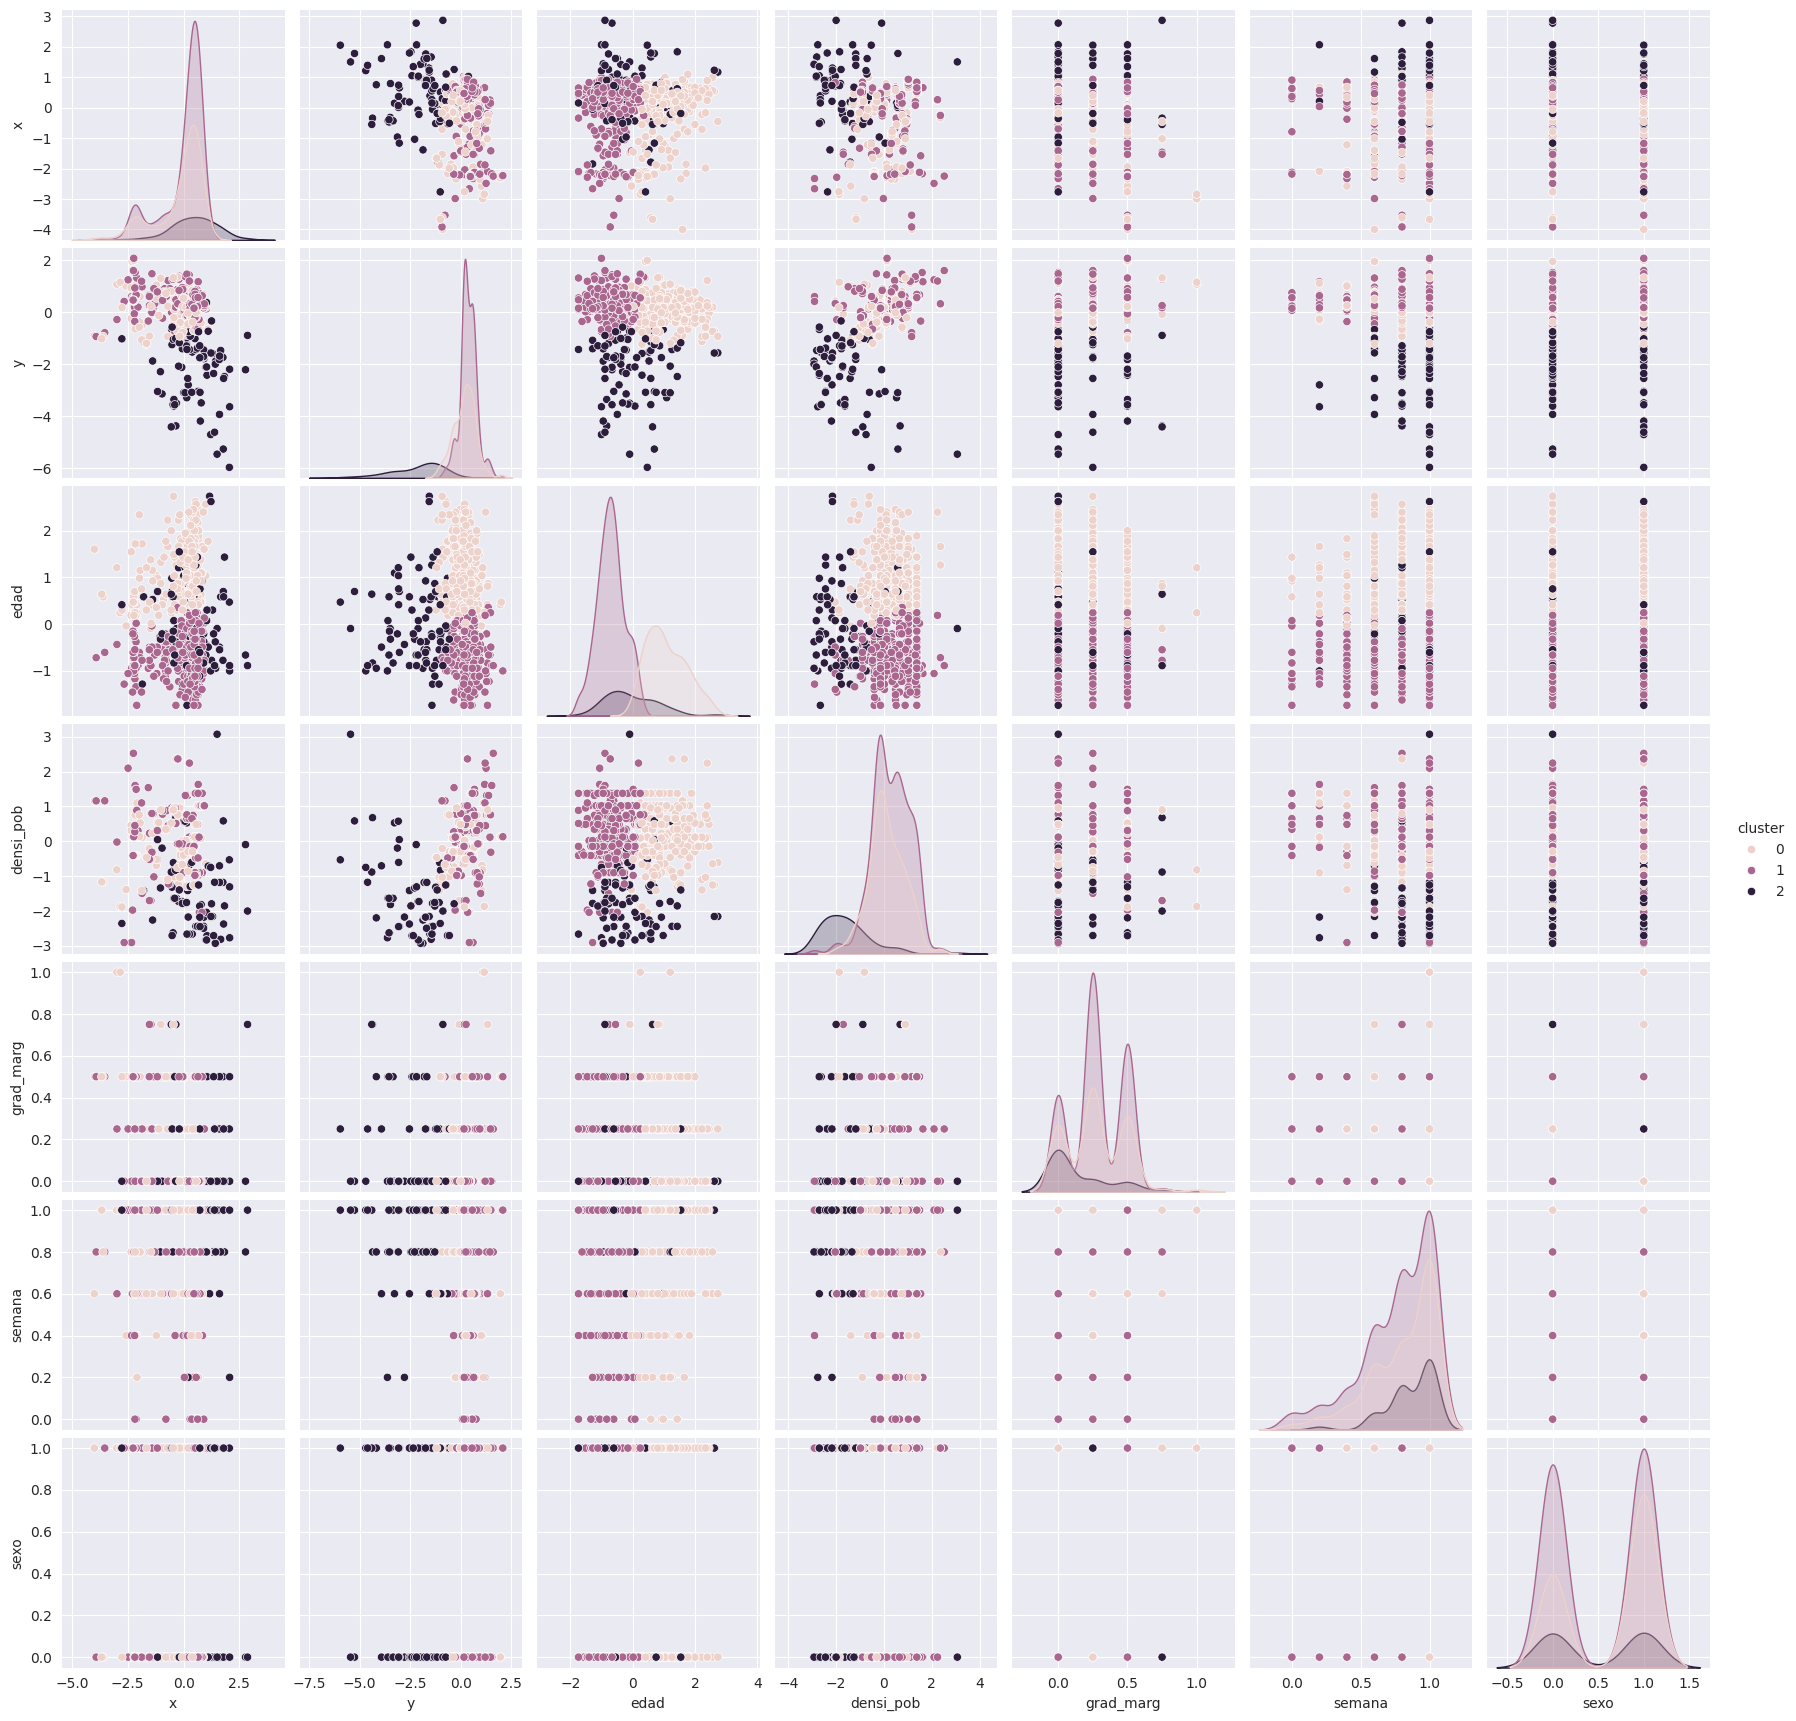

In [26]:
kmeans_sec_1_df["cluster"] = kmeans_sec_1.labels_
pairplot_kmeans_1 = sns.pairplot(kmeans_sec_1_df, hue="cluster")
filename = "./pairplot_images/pairplot_kmeans_1.png"
pairplot_kmeans_1.savefig(filename)
#pairlot_images.append(imageio.imread(filename))
pairplot_kmeans_1


/home/manuel/miniconda3/envs/fd_fhd_hmo_2010/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipykernel_12133/2967838860.py:12: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  kmeans_images.append(imageio.imread(os.path.join(folder,filename)))


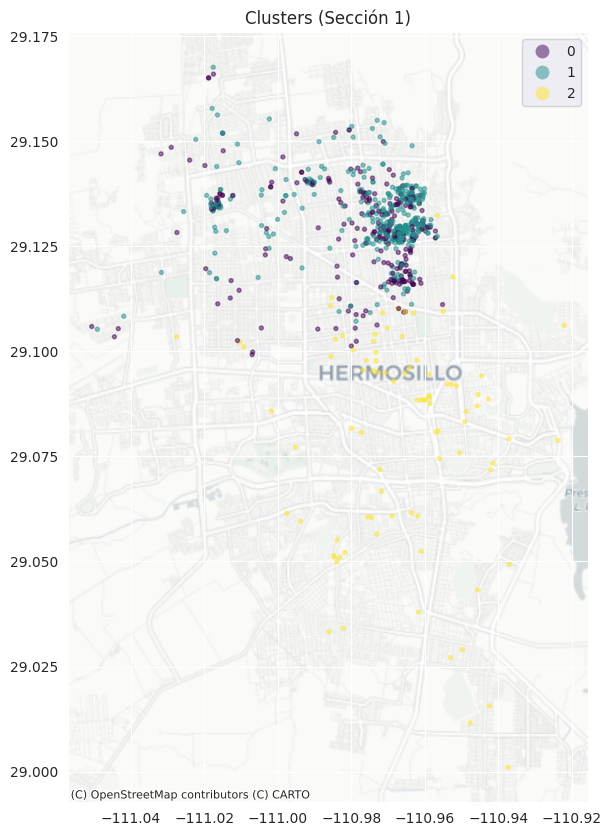

In [27]:
clusters_1 = pd.Categorical(kmeans_sec_1.labels_, categories=set(kmeans_sec_1.labels_), ordered=False)
data_sec_1["cluster"] = clusters_1

fig, ax = plt.subplots(figsize=(10, 10))
data_sec_1.plot(ax=ax, figsize=(8, 8), alpha=0.5, column="cluster", legend=True, cmap='viridis', markersize=8)
ax.set_title("Clusters (Sección 1)")

cx.add_basemap(ax=ax, crs=gdf.crs, source=cx.providers.CartoDB.Positron)

filename = 'mapa_kmeans_sec_1.png'
plt.savefig(os.path.join(folder,filename))
kmeans_images.append(imageio.imread(os.path.join(folder,filename)))


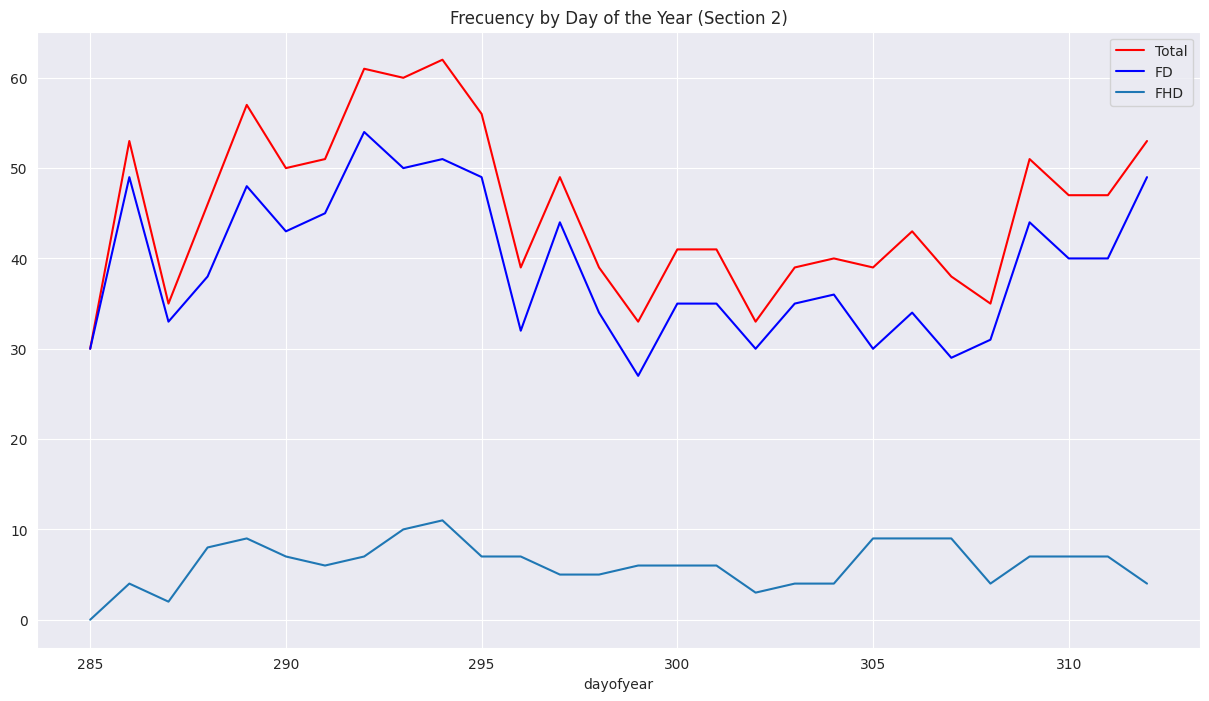

In [28]:
fig, ax = plt.subplots(figsize=(15,8))

data_sec_2_count["FD_FHD"].plot(ax=ax, color="red", label="Total")
data_sec_2_count["FD"].plot(ax=ax, color="blue")
data_sec_2_count["FHD"].plot(ax=ax)

plt.title("Frecuency by Day of the Year (Section 2)")
plt.legend()
plt.show()


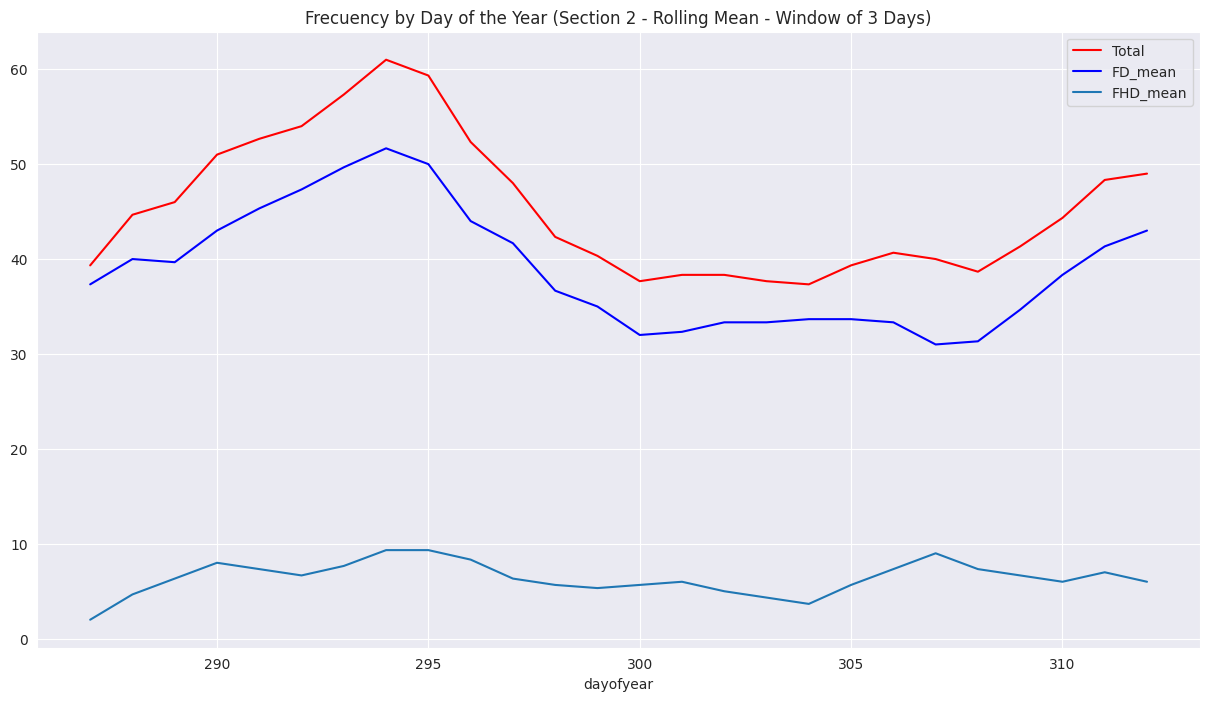

In [29]:
fig, ax = plt.subplots(figsize=(15,8))

data_sec_2_count["FD_FHD_mean"].plot(ax=ax, color="red", label="Total")
data_sec_2_count["FD_mean"].plot(ax=ax, color="blue")
data_sec_2_count["FHD_mean"].plot(ax=ax)

plt.title("Frecuency by Day of the Year (Section 2 - Rolling Mean - Window of 3 Days)")
plt.legend()
plt.show()


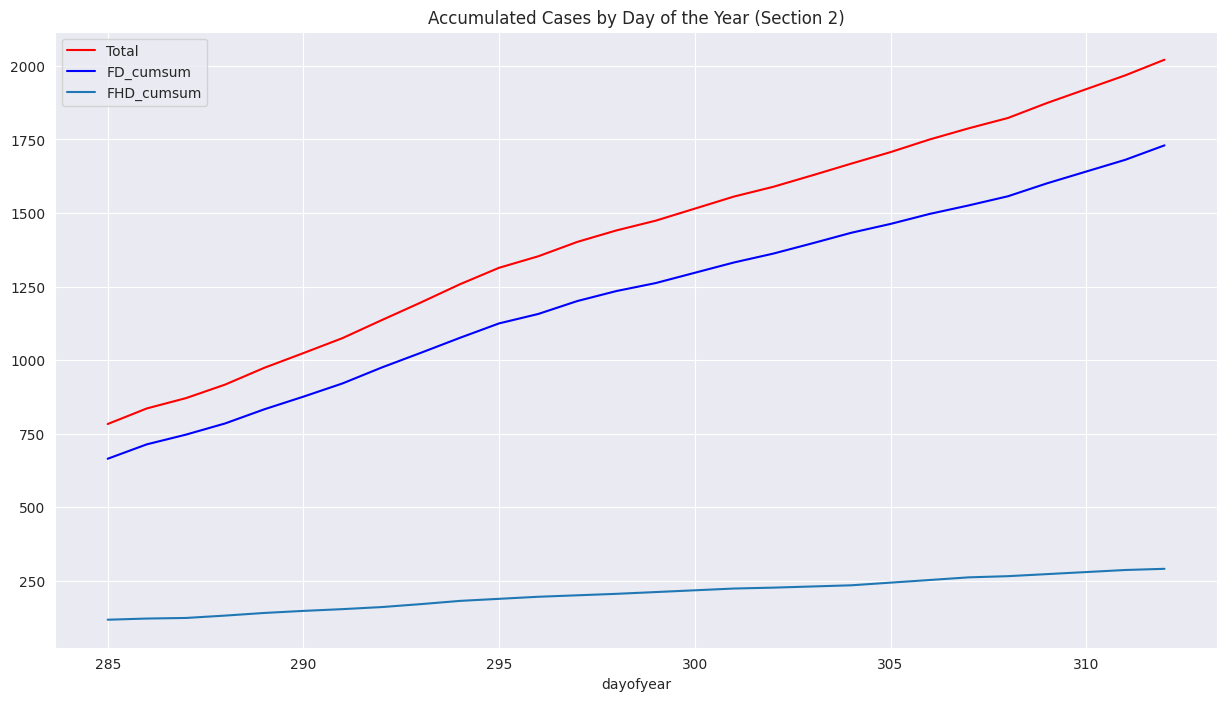

In [30]:
fig, ax = plt.subplots(figsize=(15,8))

data_sec_2_count["FD_FHD_cumsum"].plot(ax=ax, color="red", label="Total")
data_sec_2_count["FD_cumsum"].plot(ax=ax, color="blue")
data_sec_2_count["FHD_cumsum"].plot(ax=ax)
plt.title("Accumulated Cases by Day of the Year (Section 2)")
plt.legend()
plt.show()


In [31]:
kmeans_sec_2_df = data_sec_2[["x", "y", "SEXO", "EDAD", "GRADO_MA_1", "DENSI_POB", "week", "FD_FHD"]]
kmeans_sec_2_df.set_index(np.arange(len(kmeans_sec_2_df)), inplace=True)

sexo_df = pd.get_dummies(kmeans_sec_2_df["SEXO"], dtype="int", drop_first=True)
kmeans_sec_2_df = pd.concat([kmeans_sec_2_df, sexo_df], axis=1)
kmeans_sec_2_df.drop("SEXO", axis=1, inplace=True)

fd_fhd_df = pd.get_dummies(kmeans_sec_2_df["FD_FHD"], dtype="int", drop_first=True)
kmeans_sec_2_df = pd.concat([kmeans_sec_2_df, fd_fhd_df], axis=1)
kmeans_sec_2_df.drop("FD_FHD", axis=1, inplace=True)

kmeans_sec_2_df.columns = ["x", "y", "edad", "grad_marg", "densi_pob", "semana", "sexo", "FHD"]

kmeans_sec_2_df.head()

,x,y,edad,grad_marg,densi_pob,semana,sexo,FHD
0,-111.033764,29.082121,18,1,23.603304,41,0,0
1,-110.983368,29.111957,12,2,62.181259,41,0,0
2,-110.994041,29.140176,8,3,96.244148,41,1,0
3,-110.952132,29.101309,42,1,23.850897,41,1,0
4,-110.983098,29.122470,45,1,111.530258,41,1,0


In [32]:
standard_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()
standard_scaled_df = pd.DataFrame(standard_scaler.fit_transform(kmeans_sec_2_df.drop(["sexo", "grad_marg", "semana", "FHD"], axis=1)))
min_max_scaled_df = pd.DataFrame(min_max_scaler.fit_transform(kmeans_sec_2_df[["grad_marg", "semana"]]))
standard_scaled_df.columns = ["x", "y", "edad", "densi_pob"]
min_max_scaled_df.columns = ["grad_marg", "semana"]

In [33]:
kmeans_sec_2_df = pd.concat([standard_scaled_df, min_max_scaled_df, kmeans_sec_2_df["sexo"]], axis=1)
kmeans_sec_2_df.head()

,x,y,edad,densi_pob,grad_marg,semana,sexo
0,-2.397641,-0.905139,-0.796778,-1.687681,0.00,0.0,0
1,-0.202220,0.078572,-1.117444,-0.413390,0.25,0.0,0
2,-0.667193,1.008973,-1.331222,0.711761,0.50,0.0,1
3,1.158519,-0.272505,0.485889,-1.679502,0.00,0.0,1
4,-0.190453,0.425205,0.646223,1.216685,0.00,0.0,1


In [34]:
kmeans_sec_2_df.isna().sum()

x            0
y            0
edad         0
densi_pob    0
grad_marg    0
semana       0
sexo         0
dtype: int64

In [35]:
kmeans_sec_2 = KMeans(n_clusters=3).fit(kmeans_sec_2_df)
kmeans_sec_2.labels_

array([2, 2, 2, ..., 2, 0, 1], shape=(1268,), dtype=int32)

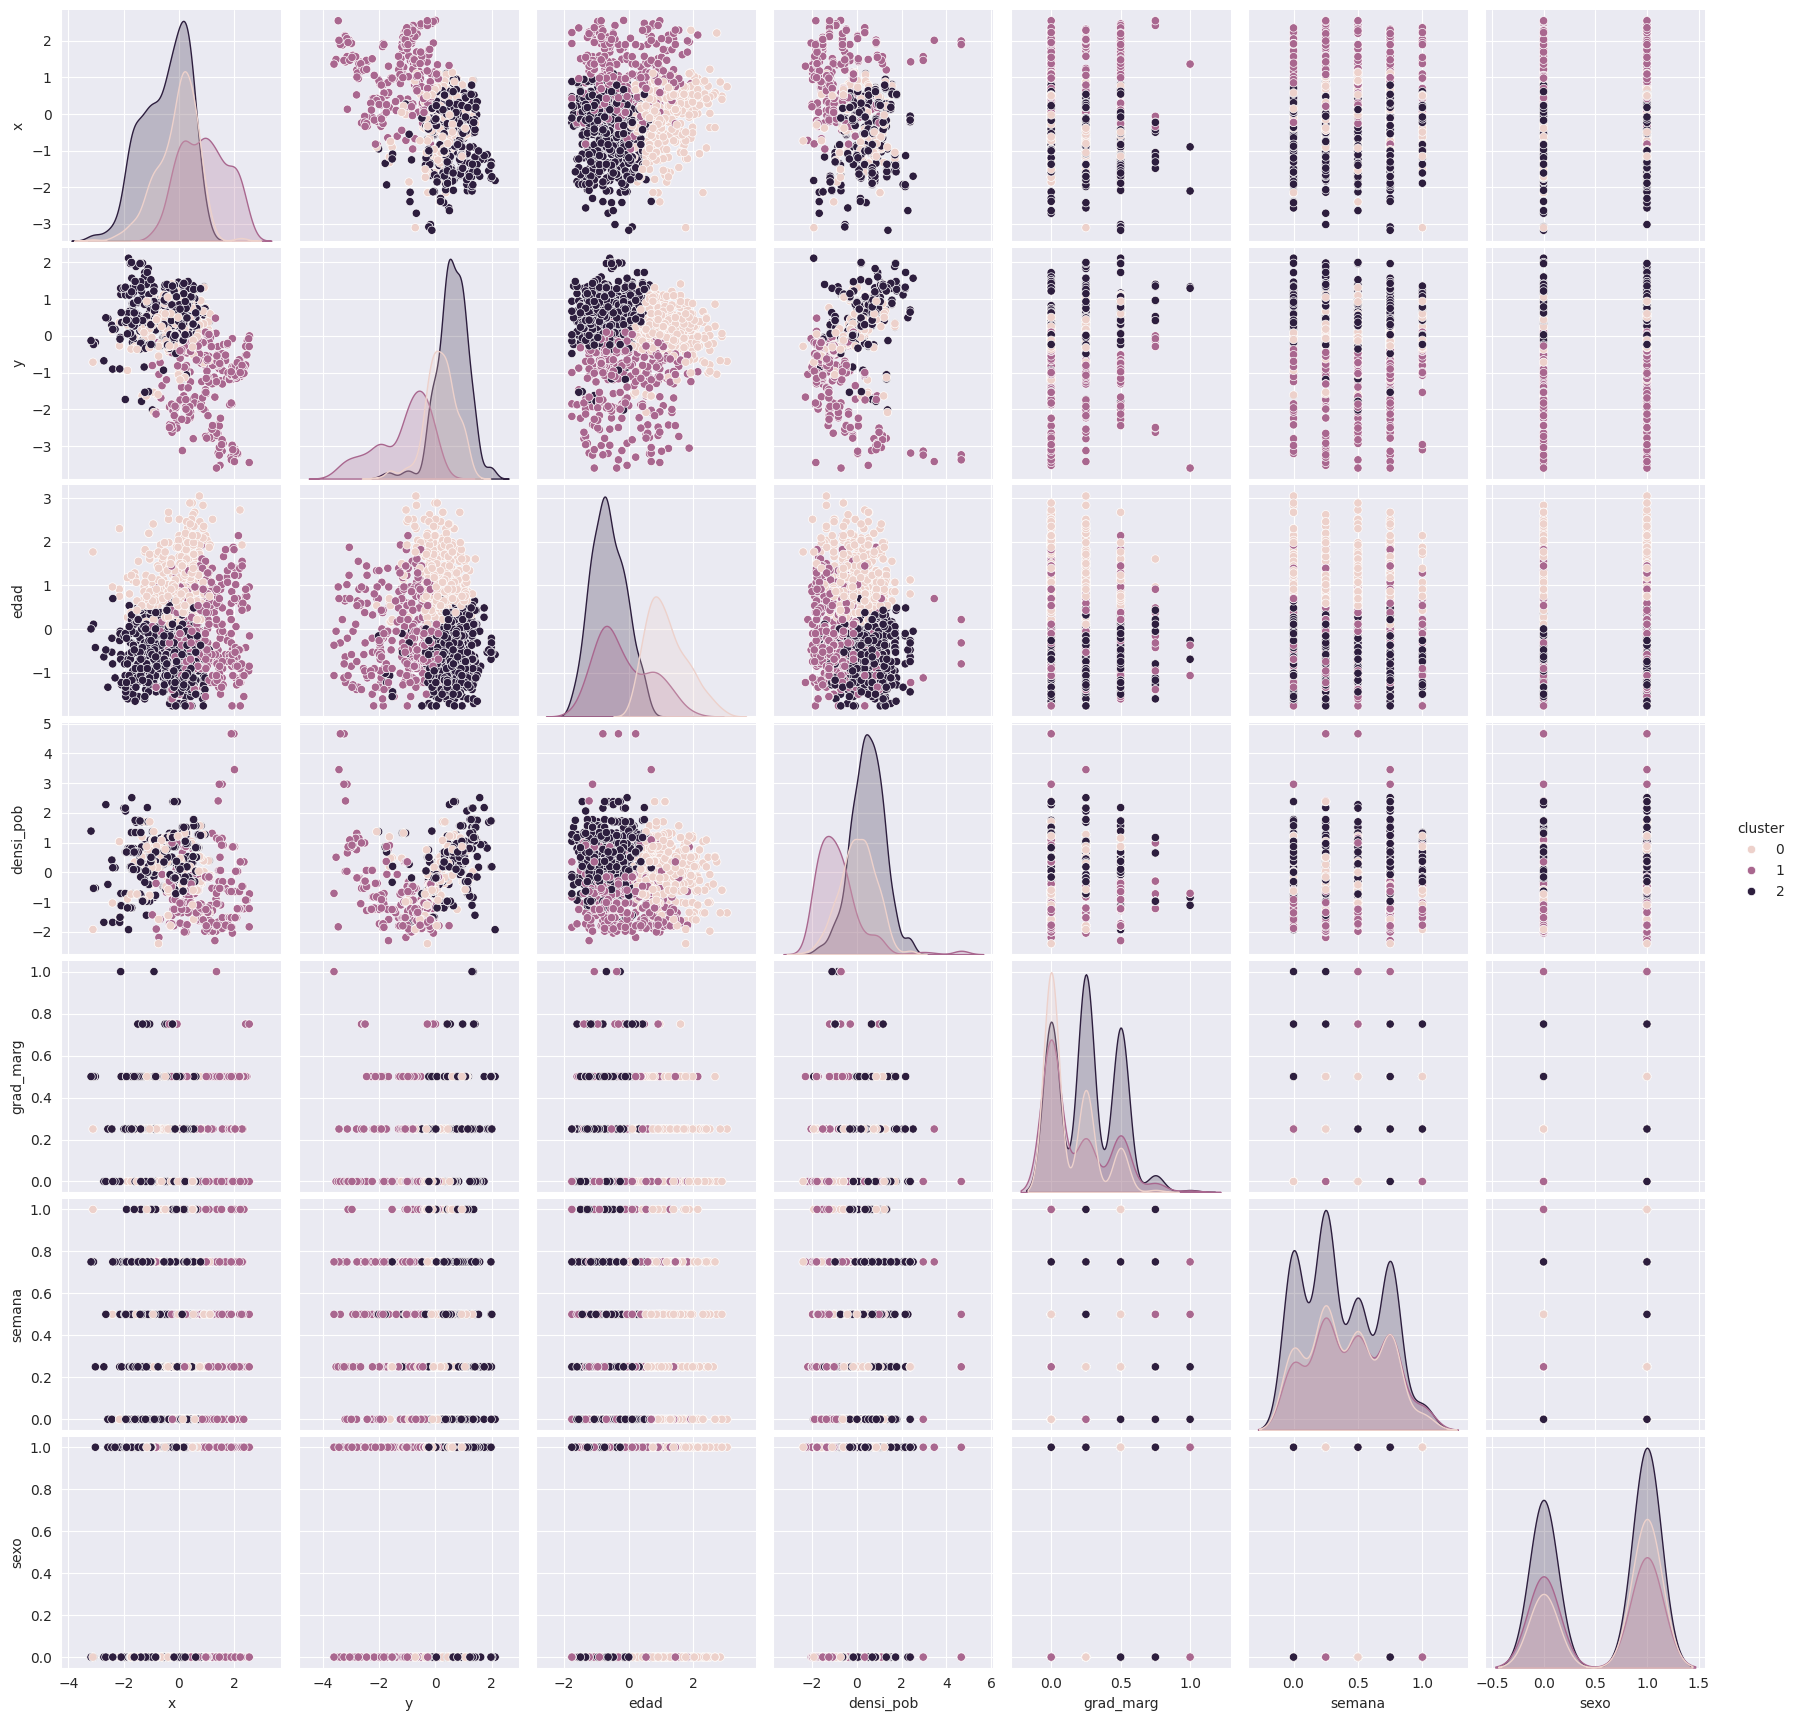

In [36]:
kmeans_sec_2_df["cluster"] = kmeans_sec_2.labels_
pairplot_kmeans_2 = sns.pairplot(kmeans_sec_2_df, hue="cluster")
filename = "./pairplot_images/pairplot_kmeans_2.png"
pairplot_kmeans_2.savefig(filename)
#pairlot_images.append(imageio.imread(filename))
pairplot_kmeans_2

/tmp/ipykernel_12133/1502031597.py:12: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  kmeans_images.append(imageio.imread(os.path.join(folder,filename)))


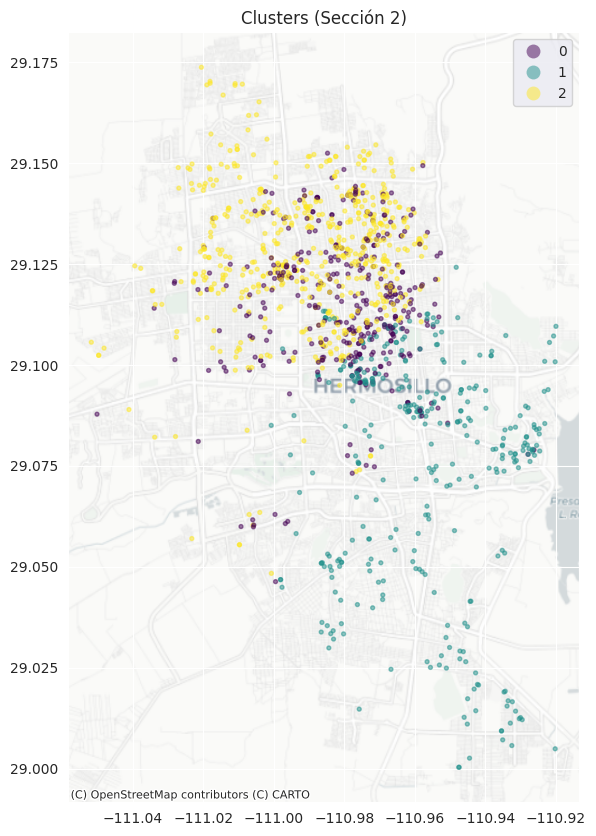

In [37]:
clusters_2 = pd.Categorical(kmeans_sec_2.labels_, categories=set(kmeans_sec_2.labels_), ordered=False)
data_sec_2["cluster"] = clusters_2

fig, ax = plt.subplots(figsize=(10, 10))
data_sec_2.plot(ax=ax, figsize=(8, 8), alpha=0.5, column="cluster", legend=True, cmap='viridis', markersize=8)
ax.set_title("Clusters (Sección 2)")

cx.add_basemap(ax=ax, crs=gdf.crs, source=cx.providers.CartoDB.Positron)

filename = 'mapa_kmeans_sec_2.png'
plt.savefig(os.path.join(folder,filename))
kmeans_images.append(imageio.imread(os.path.join(folder,filename)))


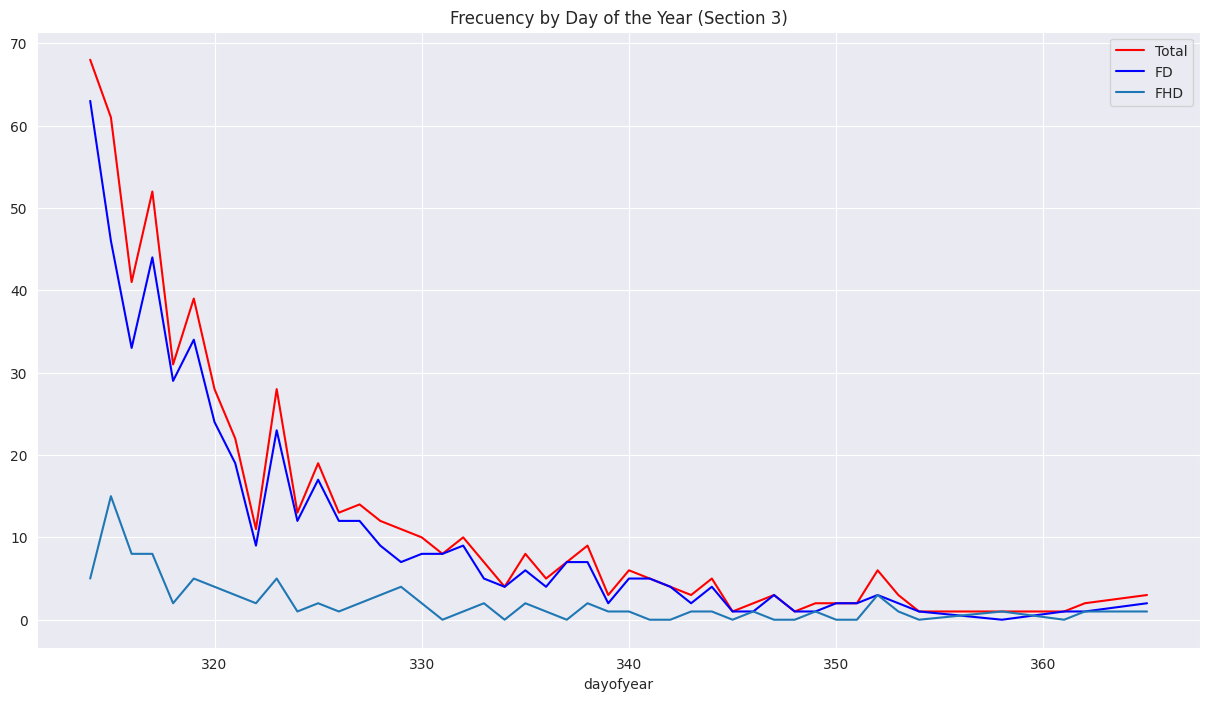

In [38]:
fig, ax = plt.subplots(figsize=(15,8))

data_sec_3_count["FD_FHD"].plot(ax=ax, color="red", label="Total")
data_sec_3_count["FD"].plot(ax=ax, color="blue")
data_sec_3_count["FHD"].plot(ax=ax)

plt.title("Frecuency by Day of the Year (Section 3)")
plt.legend()
plt.show()


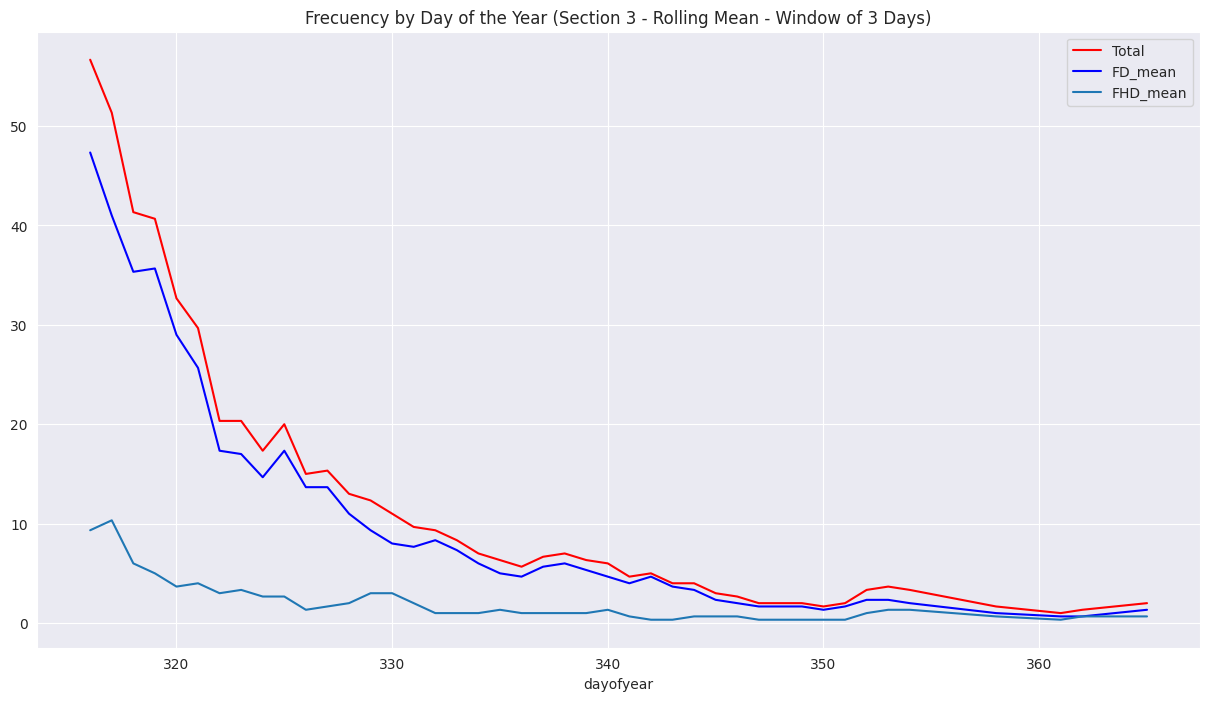

In [39]:
fig, ax = plt.subplots(figsize=(15,8))

data_sec_3_count["FD_FHD_mean"].plot(ax=ax, color="red", label="Total")
data_sec_3_count["FD_mean"].plot(ax=ax, color="blue")
data_sec_3_count["FHD_mean"].plot(ax=ax)

plt.title("Frecuency by Day of the Year (Section 3 - Rolling Mean - Window of 3 Days)")
plt.legend()
plt.show()


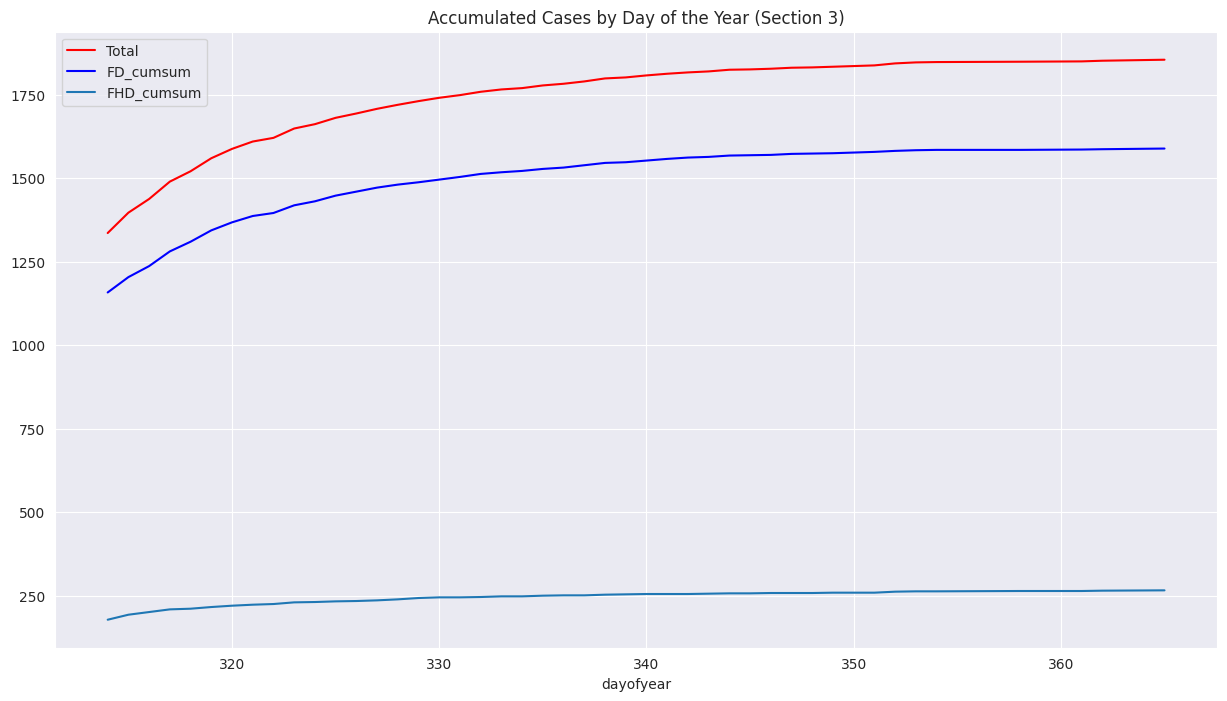

In [40]:
fig, ax = plt.subplots(figsize=(15,8))

data_sec_3_count["FD_FHD_cumsum"].plot(ax=ax, color="red", label="Total")
data_sec_3_count["FD_cumsum"].plot(ax=ax, color="blue")
data_sec_3_count["FHD_cumsum"].plot(ax=ax)
plt.title("Accumulated Cases by Day of the Year (Section 3)")
plt.legend()
plt.show()


In [41]:
kmeans_sec_3_df = data_sec_3[["x", "y", "SEXO", "EDAD", "GRADO_MA_1", "DENSI_POB", "week", "FD_FHD"]]
kmeans_sec_3_df.set_index(np.arange(len(kmeans_sec_3_df)), inplace=True)

sexo_df = pd.get_dummies(kmeans_sec_3_df["SEXO"], dtype="int", drop_first=True)
kmeans_sec_3_df = pd.concat([kmeans_sec_3_df, sexo_df], axis=1)
kmeans_sec_3_df.drop("SEXO", axis=1, inplace=True)

fd_fhd_df = pd.get_dummies(kmeans_sec_3_df["FD_FHD"], dtype="int", drop_first=True)
kmeans_sec_3_df = pd.concat([kmeans_sec_3_df, fd_fhd_df], axis=1)
kmeans_sec_3_df.drop("FD_FHD", axis=1, inplace=True)

kmeans_sec_3_df.columns = ["x", "y", "edad", "grad_marg", "densi_pob", "semana", "sexo", "FHD"]

kmeans_sec_3_df.head()

,x,y,edad,grad_marg,densi_pob,semana,sexo,FHD
0,-110.927154,29.081739,20,3,55.012966,45,1,0
1,-110.992307,29.152592,20,4,110.073723,45,0,0
2,-110.966309,29.103291,32,1,62.636532,45,0,0
3,-110.953054,29.029038,14,1,68.954155,45,0,0
4,-111.042261,29.090876,42,2,16.374422,45,0,0


In [42]:
standard_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()
standard_scaled_df = pd.DataFrame(standard_scaler.fit_transform(kmeans_sec_3_df.drop(["sexo", "grad_marg", "semana", "FHD"], axis=1)))
min_max_scaled_df = pd.DataFrame(min_max_scaler.fit_transform(kmeans_sec_3_df[["grad_marg", "semana"]]))
standard_scaled_df.columns = ["x", "y", "edad", "densi_pob"]
min_max_scaled_df.columns = ["grad_marg", "semana"]

In [43]:
kmeans_sec_3_df = pd.concat([standard_scaled_df, min_max_scaled_df, kmeans_sec_3_df["sexo"]], axis=1)
kmeans_sec_3_df.head()

,x,y,edad,densi_pob,grad_marg,semana,sexo
0,2.216068,-0.758663,-0.692293,-0.583537,0.50,0.0,1
1,-0.519133,1.369730,-0.692293,1.213584,0.75,0.0,0
2,0.572295,-0.111244,-0.008062,-0.334713,0.00,0.0,0
3,1.128733,-2.341767,-1.034408,-0.128512,0.00,0.0,0
4,-2.616263,-0.484208,0.562130,-1.844656,0.25,0.0,0


In [44]:
kmeans_sec_3_df.isna().sum()

x            0
y            0
edad         0
densi_pob    0
grad_marg    0
semana       0
sexo         0
dtype: int64

In [45]:
kmeans_sec_3 = KMeans(n_clusters=3).fit(kmeans_sec_3_df)
kmeans_sec_3.labels_

array([0, 2, 0, 0, 1, 2, 1, 0, 2, 0, 2, 2, 1, 0, 1, 2, 2, 2, 2, 1, 1, 2,
       2, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 2, 2, 2, 1, 2, 2, 1, 0, 0, 0, 2, 1, 0, 0, 2, 2,
       0, 0, 1, 2, 1, 1, 1, 2, 1, 2, 0, 0, 2, 0, 2, 1, 2, 1, 2, 1, 2, 2,
       2, 2, 0, 0, 2, 2, 2, 1, 2, 1, 2, 1, 2, 1, 2, 2, 1, 2, 0, 1, 2, 2,
       0, 2, 2, 2, 1, 2, 2, 1, 2, 0, 0, 2, 1, 1, 1, 1, 1, 1, 2, 2, 0, 1,
       1, 2, 2, 2, 2, 1, 0, 2, 1, 0, 2, 2, 2, 2, 1, 0, 2, 2, 0, 1, 2, 2,
       0, 2, 2, 1, 0, 1, 2, 2, 1, 2, 2, 2, 1, 1, 1, 1, 0, 2, 0, 0, 0, 1,
       0, 2, 2, 0, 0, 0, 0, 2, 2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 0, 1, 2,
       2, 0, 1, 1, 2, 1, 1, 0, 2, 2, 0, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2,
       2, 1, 0, 2, 0, 1, 2, 0, 0, 0, 2, 1, 2, 1, 2, 1, 0, 2, 1, 0, 0, 0,
       0, 0, 2, 1, 2, 1, 0, 2, 2, 2, 2, 0, 2, 1, 1, 1, 0, 1, 2, 0, 1, 2,
       0, 2, 1, 2, 1, 2, 1, 1, 2, 1, 1, 1, 0, 0, 2, 1, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 1, 2, 2, 0, 1, 0, 1, 0, 0, 0, 1, 1,

NameError: name 'pairlot_images' is not defined

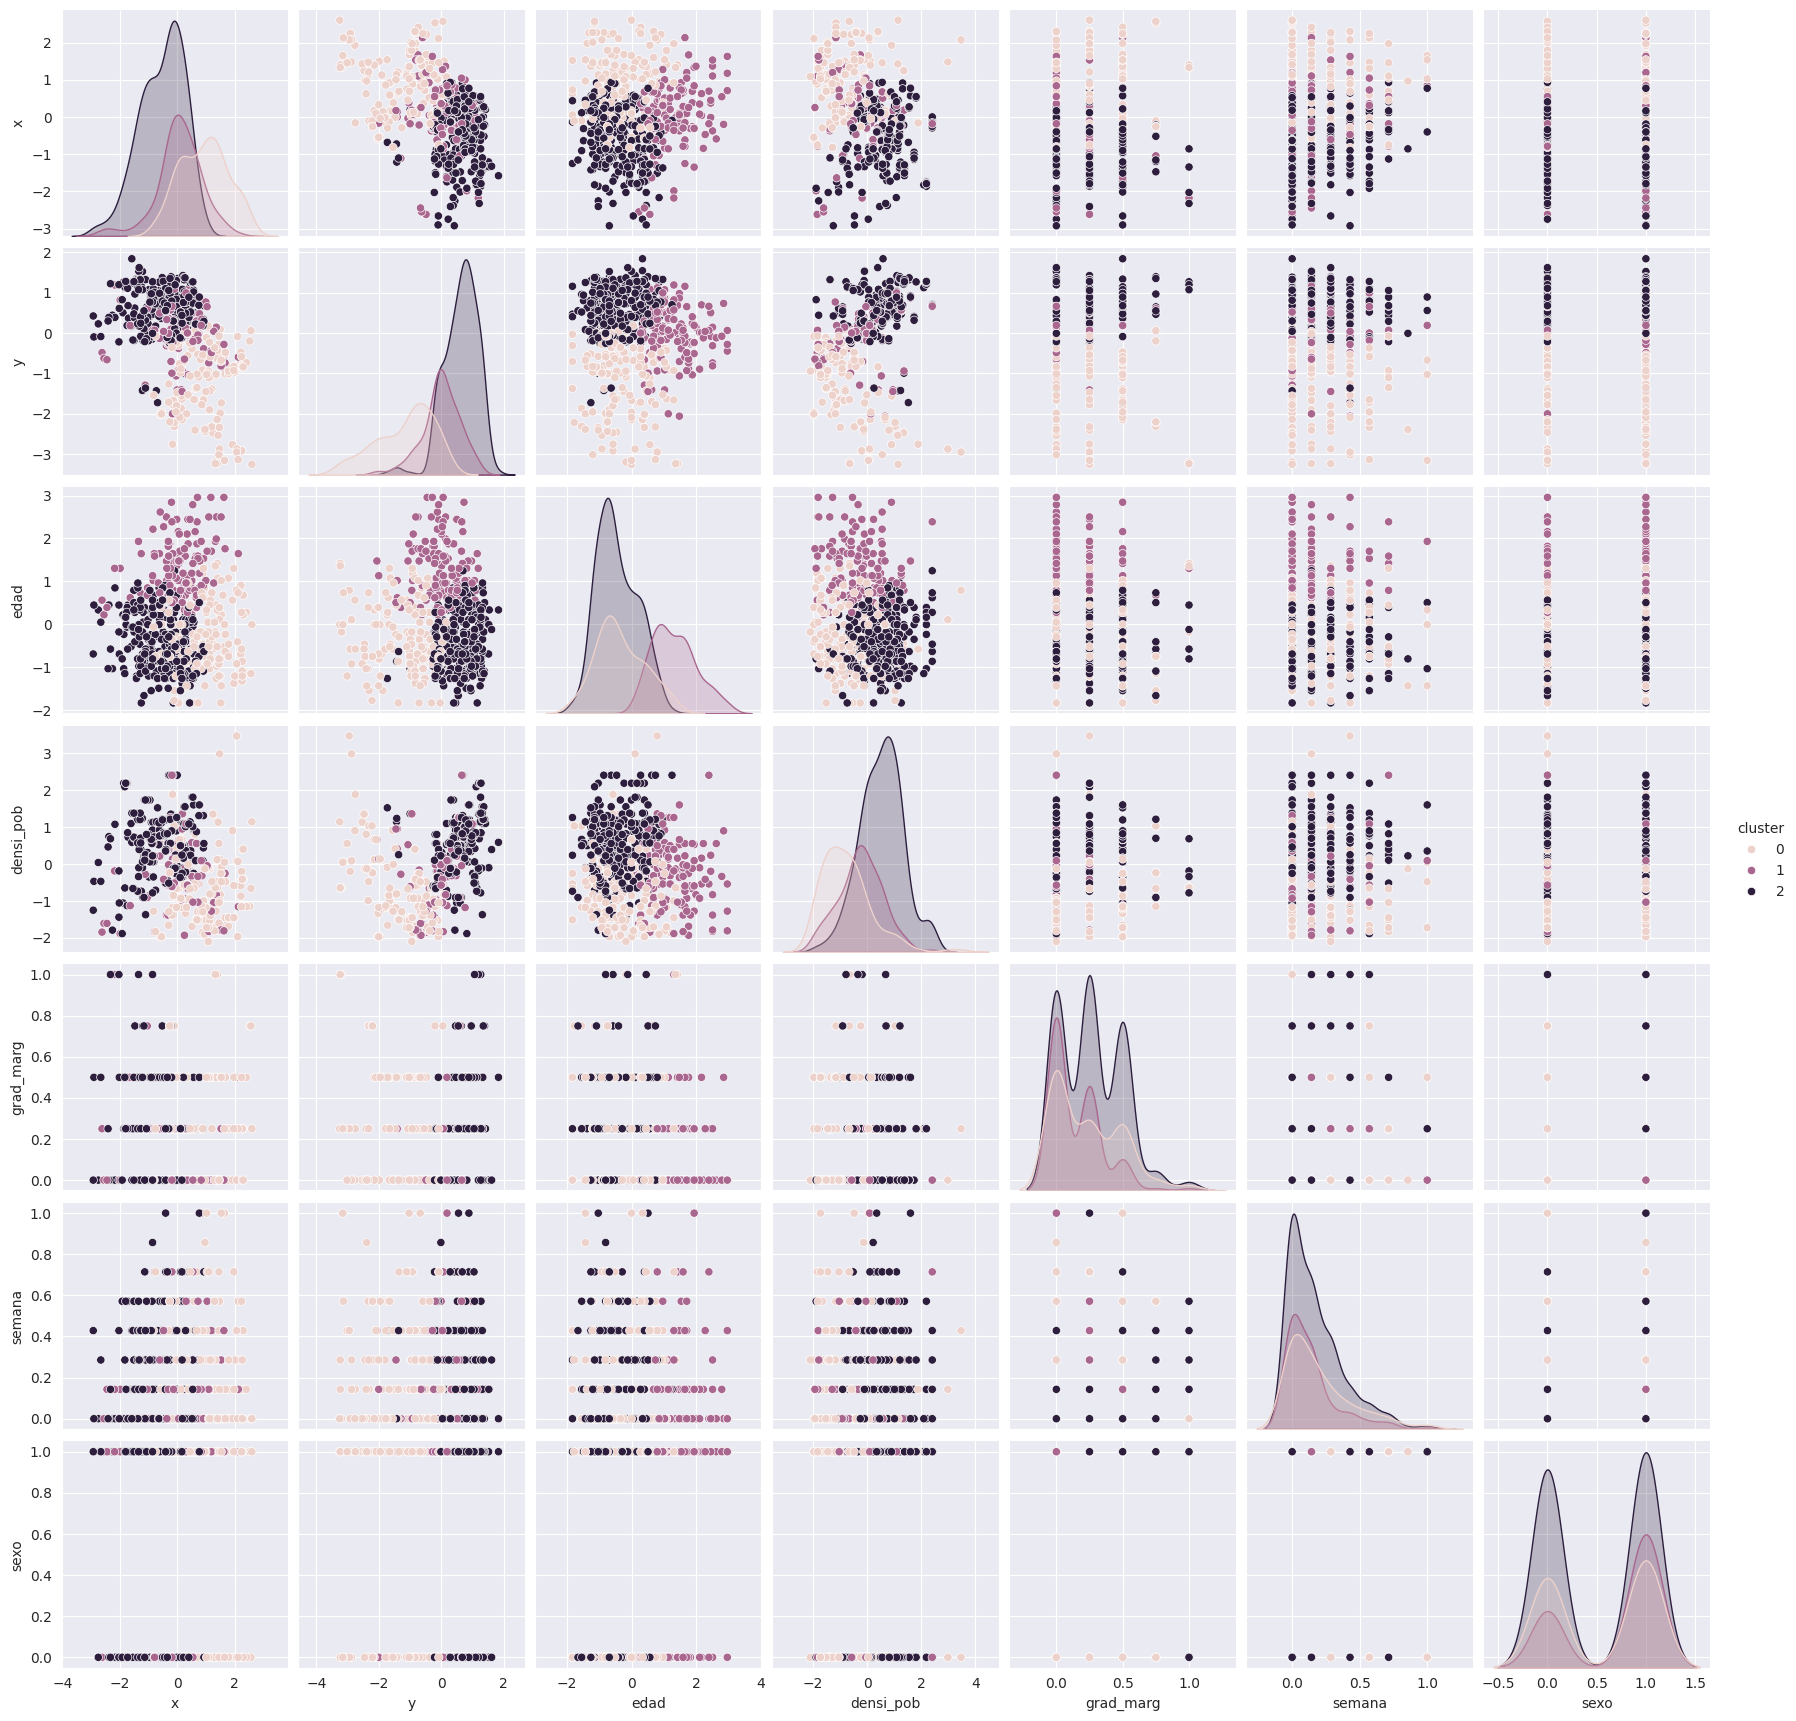

In [46]:
kmeans_sec_3_df["cluster"] = kmeans_sec_3.labels_
pairplot_kmeans_3 = sns.pairplot(kmeans_sec_3_df, hue="cluster")
filename = "./pairplot_images/pairplot_kmeans_3.png"
pairplot_kmeans_3.savefig(filename)
pairlot_images.append(imageio.imread(filename))
pairplot_kmeans_3

/home/manuelcota/miniconda3/envs/analysis_env/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipykernel_19706/1799886037.py:12: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  kmeans_images.append(imageio.imread(os.path.join(folder,filename)))


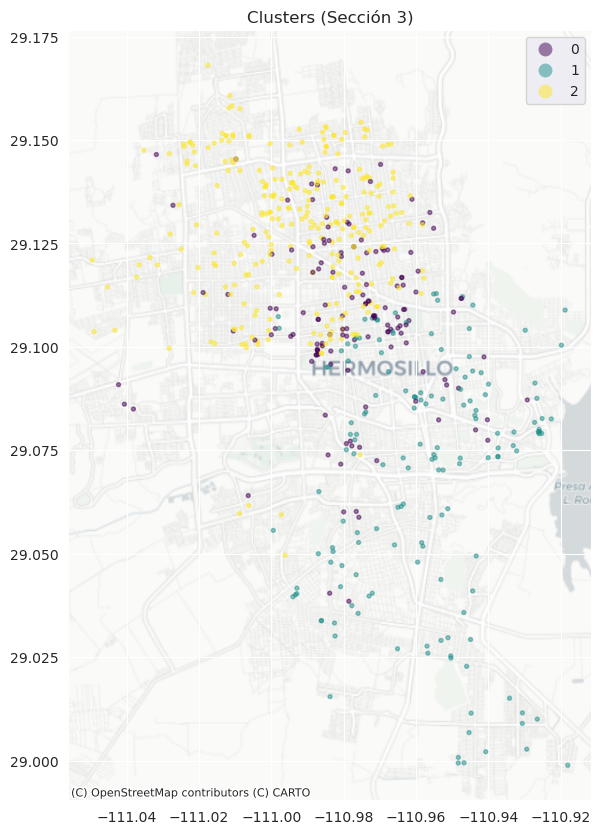

In [58]:
clusters_3 = pd.Categorical(kmeans_sec_3.labels_, categories=set(kmeans_sec_3.labels_), ordered=False)
data_sec_3["cluster"] = clusters_3

fig, ax = plt.subplots(figsize=(10, 10))
data_sec_3.plot(ax=ax, figsize=(8, 8), alpha=0.5, column="cluster", legend=True, cmap='viridis', markersize=8)
ax.set_title("Clusters (Sección 3)")

cx.add_basemap(ax=ax, crs=gdf.crs, source=cx.providers.CartoDB.Positron)

filename = 'mapa_kmeans_sec_3.png'
plt.savefig(os.path.join(folder,filename))
kmeans_images.append(imageio.imread(os.path.join(folder,filename)))


In [59]:
folder = "./kmeans_images"
imageio.mimsave(os.path.join(folder,'kmeans_map_by_section.gif'), kmeans_images, fps=2)

# Analysis by Week

In [47]:
# spike count by week

# Actual counts:
spike_count_by_week = pd.DataFrame(spike_data.groupby("week")["FD_FHD"].count())
spike_count_by_week["FD"] = spike_data.groupby("week")["FD"].sum()
spike_count_by_week["FHD"] = spike_data.groupby("week")["FHD"].sum()
# Cumulative total:
spike_count_by_week["FD_FHD_cumsum"] = spike_count_by_week["FD_FHD"].cumsum()
spike_count_by_week["FD_cumsum"] = spike_count_by_week["FD"].cumsum()
spike_count_by_week["FHD_cumsum"] = spike_count_by_week["FHD"].cumsum()
# Rolling mean:
spike_count_by_week["FD_FHD_mean"] = spike_count_by_week["FD_FHD"].rolling(3).mean()
spike_count_by_week["FD_mean"] = spike_count_by_week["FD"].rolling(3).mean()
spike_count_by_week["FHD_mean"] = spike_count_by_week["FHD"].rolling(3).mean()

spike_count_by_week.tail()

,FD_FHD,FD,FHD,FD_FHD_cumsum,FD_cumsum,FHD_cumsum,FD_FHD_mean,FD_mean,FHD_mean
week,,,,,,,,,
48,43,35,8,2652,2275,377,93.666667,79.333333,14.333333
49,26,22,4,2678,2297,381,49.000000,40.666667,8.333333
50,19,14,5,2697,2311,386,29.333333,23.666667,5.666667
51,2,1,1,2699,2312,387,15.666667,12.333333,3.333333
52,6,4,2,2705,2316,389,9.000000,6.333333,2.666667


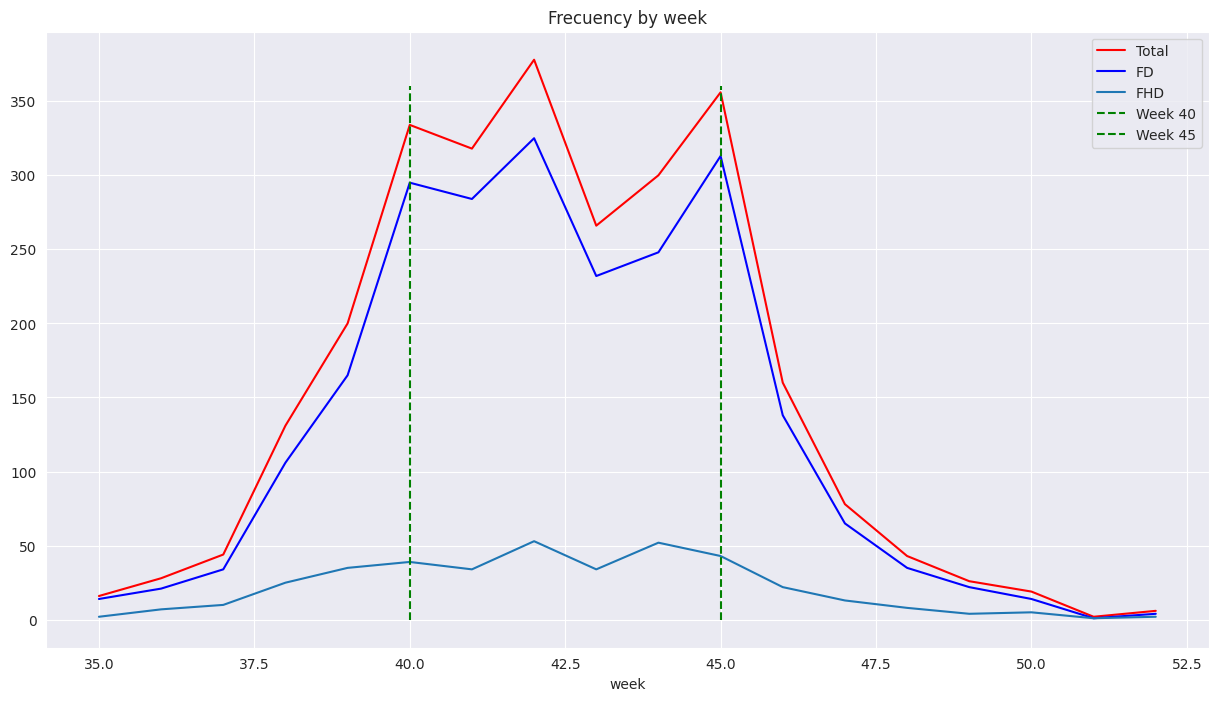

In [48]:
fig, ax = plt.subplots(figsize=(15,8))

spike_count_by_week["FD_FHD"].plot(ax=ax, color="red", label="Total")
spike_count_by_week["FD"].plot(ax=ax, color="blue")
spike_count_by_week["FHD"].plot(ax=ax)
division_1_week = 40
division_2_week = 45
plt.vlines(division_1_week, 0, 360, colors="green", linestyles='dashed', label=f"Week {division_1_week}")
plt.vlines(division_2_week, 0, 360, colors="green", linestyles='dashed', label=f"Week {division_2_week}")

plt.title("Frecuency by week")
plt.legend()
plt.show()

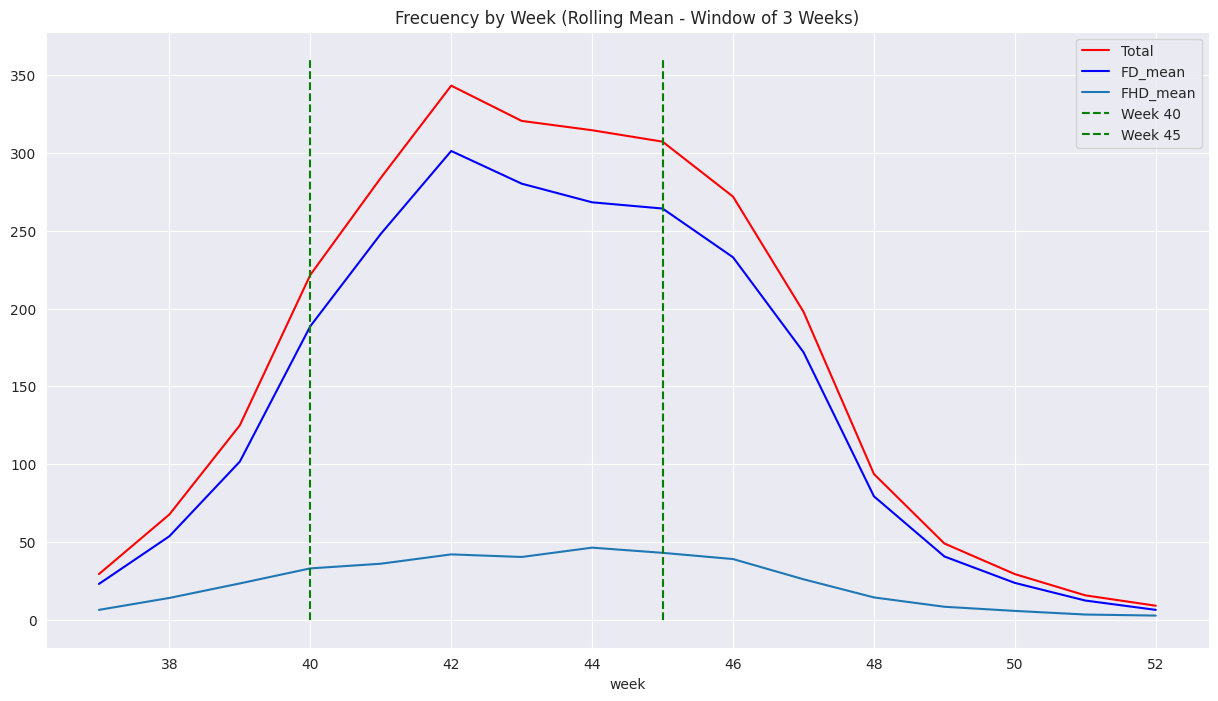

In [49]:
fig, ax = plt.subplots(figsize=(15,8))

spike_count_by_week["FD_FHD_mean"].plot(ax=ax, color="red", label="Total")
spike_count_by_week["FD_mean"].plot(ax=ax, color="blue")
spike_count_by_week["FHD_mean"].plot(ax=ax)
division_1_week = 40
division_2_week = 45
plt.vlines(division_1_week, 0, 360, colors="green", linestyles='dashed', label=f"Week {division_1_week}")
plt.vlines(division_2_week, 0, 360, colors="green", linestyles='dashed', label=f"Week {division_2_week}")

plt.title("Frecuency by Week (Rolling Mean - Window of 3 Weeks)")
plt.legend()
plt.show()

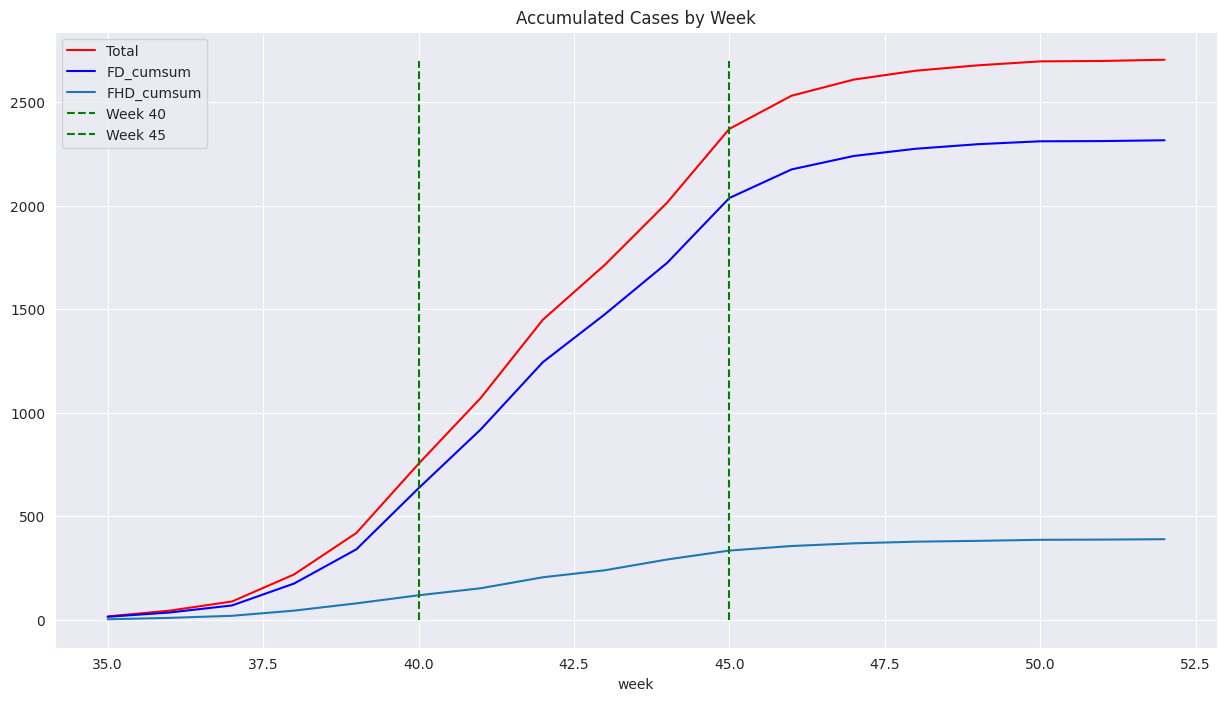

In [50]:
fig, ax = plt.subplots(figsize=(15,8))

spike_count_by_week["FD_FHD_cumsum"].plot(ax=ax, color="red", label="Total")
spike_count_by_week["FD_cumsum"].plot(ax=ax, color="blue")
spike_count_by_week["FHD_cumsum"].plot(ax=ax)
plt.vlines(division_1_week, 0, 2700, colors="green", linestyles='dashed', label=f"Week {division_1_week}")
plt.vlines(division_2_week, 0, 2700, colors="green", linestyles='dashed', label=f"Week {division_2_week}")

plt.title("Accumulated Cases by Week")
plt.legend()
plt.show()